In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/kidney_stone_project_2

/content/drive/MyDrive/kidney_stone_project_2


In [3]:
!pip install -q -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 7.7 MB/s eta 0:00:00


In [4]:
!nvidia-smi
!python src/check_environment.py

Tue Sep  1 03:35:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!python src/download_data.py --config configs/config.yaml

Dataset: murillobouzon/kssd2025-kidney-stone-segmentation-dataset
Saqlash papkasi: /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025
100% 78.5M/78.5M [00:00<00:00, 139MB/s]
Extracting files...

Dataset yuklandi.
KaggleHub qaytargan path: /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025
Project raw path: /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025
Topilgan fayllar: 1677
 - .complete/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset/1/bundle.complete
 - data/image/1.tif
 - data/image/10.tif
 - data/image/1000.tif
 - data/image/1001.tif
 - data/image/1002.tif
 - data/image/1003.tif
 - data/image/1012.tif
 - data/image/1013.tif
 - data/image/1014.tif
 - data/image/1015.tif
 - data/image/1020.tif
 - data/image/1021.tif
 - data/image/1022.tif
 - data/image/1023.tif
 - data/image/1024.tif
 - data/image/1025.tif
 - data/image/1026.tif
 - data/image/1027.tif
 - data/image/1028.tif


In [6]:
!python src/inspect_data.py \
    --config configs/config.yaml \
    --limit 80

Dataset root: /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025
Jami fayl: 1677
Extensionlar: Counter({'.tif': 1676, '.complete': 1})

Birinchi fayllar:
 - .complete/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset/1/bundle.complete
 - data/image/1.tif
 - data/image/10.tif
 - data/image/1000.tif
 - data/image/1001.tif
 - data/image/1002.tif
 - data/image/1003.tif
 - data/image/1012.tif
 - data/image/1013.tif
 - data/image/1014.tif
 - data/image/1015.tif
 - data/image/1020.tif
 - data/image/1021.tif
 - data/image/1022.tif
 - data/image/1023.tif
 - data/image/1024.tif
 - data/image/1025.tif
 - data/image/1026.tif
 - data/image/1027.tif
 - data/image/1028.tif
 - data/image/1029.tif
 - data/image/1030.tif
 - data/image/1031.tif
 - data/image/1032.tif
 - data/image/1033.tif
 - data/image/1034.tif
 - data/image/1035.tif
 - data/image/1036.tif
 - data/image/1037.tif
 - data/image/1038.tif
 - data/image/1039.tif
 - data/image/1040.tif
 - data/image/1041.tif
 - da

In [7]:
!python src/prepare_data.py --config configs/config.yaml

1-BO'LIM: image-mask juftlarini qidirish
Topilgan juftliklar: 838

2-BO'LIM: masklarda haqiqiy foreground borligini tekshirish
Stone pixel > 0 bo'lgan masklar: 838 / 838
Median stone pixels: 305.5

3-BO'LIM: image-level train/val/test split
{'total_pairs': 838, 'train': 586, 'val': 126, 'test': 126, 'positive_masks': 838, 'median_stone_pixels': 305.5, 'split_level': 'image-level', 'note': "Agar patient ID mavjud bo'lsa, keyinchalik patient/group-level split tavsiya qilinadi."}


In [8]:
!python src/visualize_sample.py --config configs/config.yaml

Saqlandi: /content/drive/MyDrive/kidney_stone_project_2/results/figures/sample_overlay.png


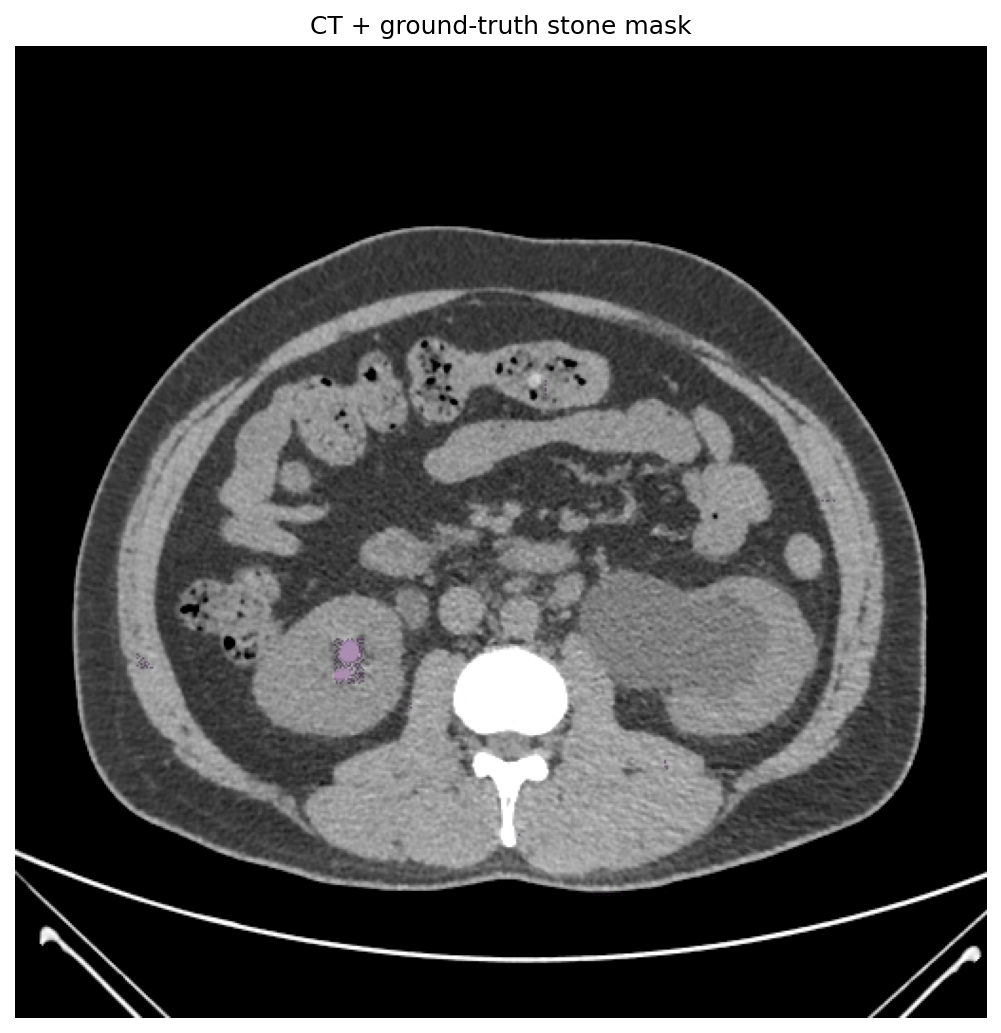

In [9]:
from IPython.display import Image, display

display(
    Image(
        filename="results/figures/sample_overlay.png"
    )
)

In [16]:
from pathlib import Path

root = Path("data")

files = sorted(
    list(root.rglob("*.tif")) +
    list(root.rglob("*.tiff"))
)

for p in files[:50]:
    print(p)

data/raw/kssd2025/data/image/1.tif
data/raw/kssd2025/data/image/10.tif
data/raw/kssd2025/data/image/1000.tif
data/raw/kssd2025/data/image/1001.tif
data/raw/kssd2025/data/image/1002.tif
data/raw/kssd2025/data/image/1003.tif
data/raw/kssd2025/data/image/1012.tif
data/raw/kssd2025/data/image/1013.tif
data/raw/kssd2025/data/image/1014.tif
data/raw/kssd2025/data/image/1015.tif
data/raw/kssd2025/data/image/1020.tif
data/raw/kssd2025/data/image/1021.tif
data/raw/kssd2025/data/image/1022.tif
data/raw/kssd2025/data/image/1023.tif
data/raw/kssd2025/data/image/1024.tif
data/raw/kssd2025/data/image/1025.tif
data/raw/kssd2025/data/image/1026.tif
data/raw/kssd2025/data/image/1027.tif
data/raw/kssd2025/data/image/1028.tif
data/raw/kssd2025/data/image/1029.tif
data/raw/kssd2025/data/image/1030.tif
data/raw/kssd2025/data/image/1031.tif
data/raw/kssd2025/data/image/1032.tif
data/raw/kssd2025/data/image/1033.tif
data/raw/kssd2025/data/image/1034.tif
data/raw/kssd2025/data/image/1035.tif
data/raw/kssd2025

In [11]:
!python src/visualize_sample.py --config configs/config.yaml

Saqlandi: /content/drive/MyDrive/kidney_stone_project_2/results/figures/sample_overlay.png


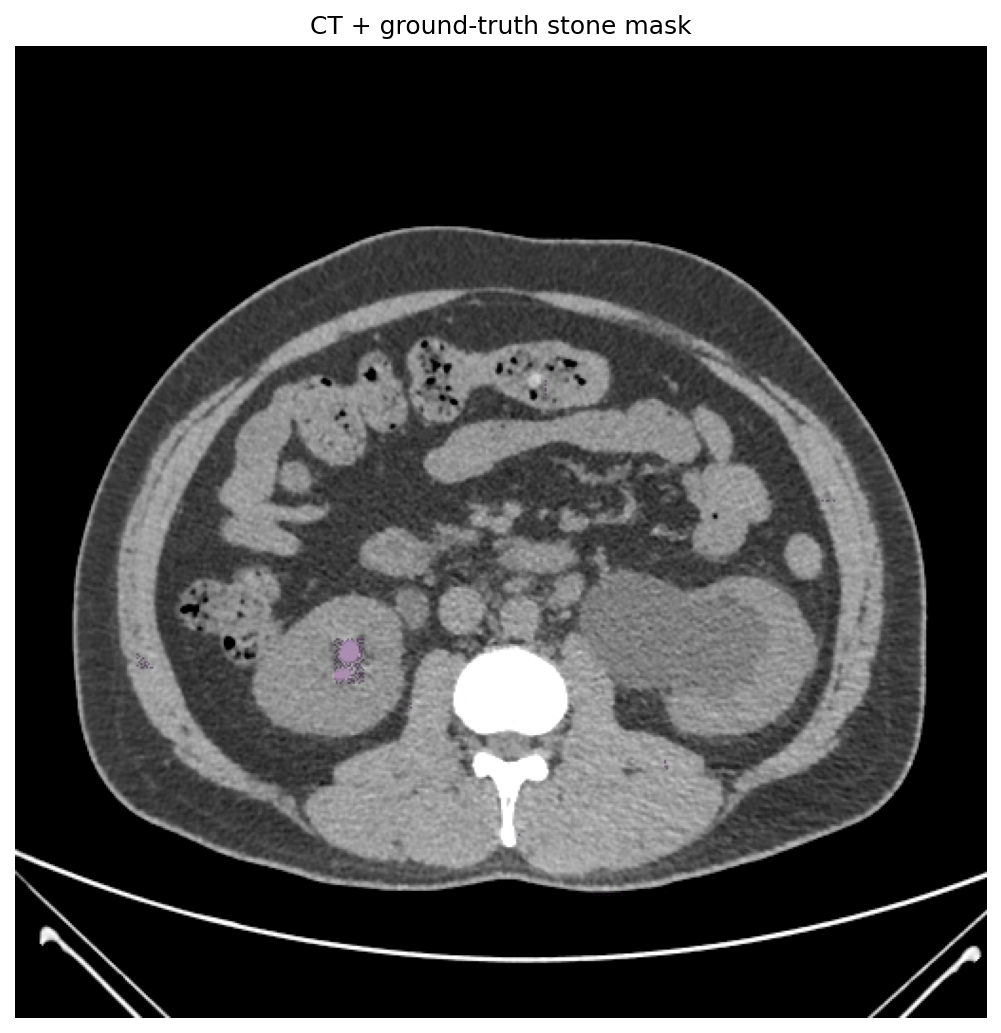

In [17]:
from IPython.display import Image, display

display(
    Image(filename="results/figures/sample_overlay.png")
)

In [13]:
from pathlib import Path
import numpy as np
from PIL import Image
from scipy.ndimage import label

# Misol sifatida birinchi mask
mask_dir = Path("data/raw/kssd2025/data/mask")

mask_path = sorted(mask_dir.glob("*.tif"))[0]

mask = np.array(Image.open(mask_path))

# Binary mask
binary = mask > 0

# Alohida obyektlarni topish
labeled, num_objects = label(binary)

print("Mask:", mask_path)
print("Mask shape:", mask.shape)
print("Unique values:", np.unique(mask))
print("Foreground pixels:", binary.sum())
print("Connected components:", num_objects)

for i in range(1, num_objects + 1):
    area = (labeled == i).sum()
    print(f"Component {i}: {area} pixels")

IndexError: list index out of range

In [14]:
!python src/train.py --config configs/config.yaml

2026-09-01 03:51:45.469714: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Device: cuda
Epoch 1/12 train: 100% 74/74 [00:10<00:00,  6.84it/s]
Epoch 1/12 val: 100% 16/16 [00:01<00:00, 10.45it/s]
{'epoch': 1, 'train_loss': 1.6811841380474104, 'val_loss': 1.6319822583879744, 'val_dice': 0.009218330600391504}
Yangi best model saqlandi: Dice=0.0092
Epoch 2/12 train: 100% 74/74 [00:09<00:00,  8.13it/s]
Epoch 2/12 val: 100% 16/16 [00:01<00:00,  9.75it/s]
{'epoch': 2, 'train_loss': 1.6212467268465323, 'val_loss': 1.6128337913089328, 'val_dice': 0.02185219855377386}
Yangi best model saqlandi: Dice=0.0219
Epoch 3/12 train: 100% 74/74 [00:08<00:00,  9.24it/s]
Epoch 3/12 val: 100% 16/16 [00:03<00:00,  5.18it/s]
{'epoch': 3, 'train_loss': 1.6059580785015743,

In [18]:
# ============================================================
# VALIDATION THRESHOLD DIAGNOSTIC
# Bu kod model stone uchun qanday probability berayotganini
# va qaysi threshold eng yaxshi Dice berishini tekshiradi.
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

sys.path.append("src")

from common import load_config, resolve_path
from dataset import KidneyStoneDataset
from model import build_model


# ------------------------------------------------------------
# 1-BO'LIM:
# Config va validation datasetni yuklash
# ------------------------------------------------------------

cfg = load_config("configs/config.yaml")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

splits_dir = resolve_path(cfg["data"]["splits_dir"])

val_df = pd.read_csv(
    splits_dir / "val.csv"
)

image_size = tuple(
    int(x) for x in cfg["data"]["image_size"]
)

val_ds = KidneyStoneDataset(
    val_df,
    image_size=image_size,
    augment=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2
)


# ------------------------------------------------------------
# 2-BO'LIM:
# Hozirgi best modelni yuklash
# ------------------------------------------------------------

model = build_model(cfg).to(device)

checkpoint = torch.load(
    "models/best_2d_unet.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model"]
)

model.eval()


# ------------------------------------------------------------
# 3-BO'LIM:
# Validation dataset uchun probabilitylarni yig'ish
# ------------------------------------------------------------

all_probs = []
all_targets = []

with torch.no_grad():

    for batch in val_loader:

        x = batch["image"].to(device)
        y = batch["mask"].to(device)

        logits = model(x)

        probs = torch.sigmoid(logits)

        all_probs.append(
            probs.cpu()
        )

        all_targets.append(
            y.cpu()
        )


probs = torch.cat(all_probs, dim=0)
targets = torch.cat(all_targets, dim=0)


# ------------------------------------------------------------
# 4-BO'LIM:
# Model probability statistikasi
# ------------------------------------------------------------

print("\n===== PROBABILITY STATISTICS =====")

print(
    "Probability min :",
    probs.min().item()
)

print(
    "Probability mean:",
    probs.mean().item()
)

print(
    "Probability max :",
    probs.max().item()
)

foreground_ratio = (
    targets.sum() / targets.numel()
).item()

print(
    "\nTrue foreground ratio:",
    foreground_ratio
)

print(
    "True foreground %:",
    foreground_ratio * 100
)


# ------------------------------------------------------------
# 5-BO'LIM:
# Turli thresholdlarni tekshirish
# ------------------------------------------------------------

print("\n===== THRESHOLD SEARCH =====")

best_threshold = None
best_dice = -1

for threshold in np.arange(
    0.05,
    0.96,
    0.05
):

    pred = (
        probs >= threshold
    ).float()

    intersection = (
        pred * targets
    ).sum().item()

    denominator = (
        pred.sum().item()
        +
        targets.sum().item()
    )

    dice = (
        2 * intersection + 1e-7
    ) / (
        denominator + 1e-7
    )

    predicted_ratio = (
        pred.sum() / pred.numel()
    ).item()

    print(
        f"threshold={threshold:.2f} | "
        f"dice={dice:.4f} | "
        f"pred_fg={predicted_ratio*100:.4f}%"
    )

    if dice > best_dice:

        best_dice = dice
        best_threshold = threshold


print("\n==============================")

print(
    "BEST THRESHOLD:",
    round(best_threshold, 2)
)

print(
    "BEST DICE:",
    round(best_dice, 4)
)

print("==============================")

Device: cuda

===== PROBABILITY STATISTICS =====
Probability min : 4.996989395036408e-18
Probability mean: 0.4519200623035431
Probability max : 0.9939178228378296

True foreground ratio: 0.0013470120029523969
True foreground %: 0.1347012002952397

===== THRESHOLD SEARCH =====
threshold=0.05 | dice=0.0027 | pred_fg=99.9705%
threshold=0.10 | dice=0.0027 | pred_fg=99.9604%
threshold=0.15 | dice=0.0027 | pred_fg=99.9510%
threshold=0.20 | dice=0.0027 | pred_fg=99.9420%
threshold=0.25 | dice=0.0027 | pred_fg=99.9326%
threshold=0.30 | dice=0.0027 | pred_fg=99.9211%
threshold=0.35 | dice=0.0027 | pred_fg=99.9064%
threshold=0.40 | dice=0.0027 | pred_fg=99.8763%
threshold=0.45 | dice=0.0061 | pred_fg=38.8223%
threshold=0.50 | dice=0.0250 | pred_fg=0.6280%
threshold=0.55 | dice=0.0016 | pred_fg=0.2221%
threshold=0.60 | dice=0.0007 | pred_fg=0.1294%
threshold=0.65 | dice=0.0006 | pred_fg=0.0848%
threshold=0.70 | dice=0.0004 | pred_fg=0.0569%
threshold=0.75 | dice=0.0004 | pred_fg=0.0402%
threshold

In [20]:
%cd /content/drive/MyDrive/kidney_stone_project_2

/content/drive/MyDrive/kidney_stone_project_2


In [21]:
%%writefile configs/config.yaml

project:
  name: kidney_stone_2d_segmentation_kssd2025
  seed: 42

data:
  raw_dir: data/raw/kssd2025
  manifest_csv: data/processed/manifest.csv
  splits_dir: data/splits

  test_size: 0.15
  val_size: 0.15

  # Stone juda kichik bo'lgani uchun 256 emas,
  # originalga yaqin 512x512 resolution ishlatamiz.
  image_size: [512, 512]

training:
  # Juda uzoq training qilmaymiz.
  epochs: 15

  # 512x512 T4 VRAM uchun xavfsizroq.
  batch_size: 4

  learning_rate: 0.0002
  weight_decay: 0.00001

  num_workers: 2

  # T4 GPUda VRAMni tejaydi va trainingni tezlashtiradi.
  amp: true

  # Oldingi 3 juda qisqa edi.
  early_stopping_patience: 5

  threshold: 0.5

model:
  in_channels: 1
  out_channels: 1

  # Oldingi model 4 marta downsample qilardi.
  # Stone juda kichik bo'lgani uchun faqat 3 marta qilamiz.
  channels: [16, 32, 64, 128]
  strides: [2, 2, 2]

  num_res_units: 2
  dropout: 0.0

postprocess:
  min_component_pixels: 3

paths:
  best_model: models/best_2d_unet.pth
  last_checkpoint: models/last_checkpoint.pth

  history_csv: results/metrics/training_history.csv

  test_csv: results/metrics/test_metrics.csv
  test_summary: results/metrics/test_summary.json

  sample_figure: results/figures/sample_overlay.png

  prediction_dir: results/predictions

Overwriting configs/config.yaml


In [22]:
%%writefile src/losses.py

"""
Kidney stone kabi juda kichik foreground uchun loss funksiyasi.

Bu datasetda stone pixel juda kam (~0.1% atrofida).
Oddiy BCE backgroundni juda kuchli o'rganib qolishi mumkin.

Shuning uchun:
1. Weighted BCE
2. Tversky Loss

birgalikda ishlatiladi.
"""

from __future__ import annotations

import torch
import torch.nn.functional as F


def dice_bce_loss(
    logits: torch.Tensor,
    targets: torch.Tensor
) -> torch.Tensor:
    """
    Funksiya nomi eski train.py bilan moslik uchun
    dice_bce_loss bo'lib qoldi.

    Lekin ichida:
        Weighted BCE + Tversky Loss
    ishlatiladi.
    """

    # ==========================================================
    # 1-BO'LIM: Weighted BCE
    #
    # Stone pixel juda kam.
    # pos_weight > 1 stone pixellarga ko'proq ahamiyat beradi.
    #
    # Datasetdagi nazariy inverse ratio ~700+ bo'lishi mumkin,
    # lekin juda katta weight trainingni beqaror qilishi mumkin.
    # Shu sabab konservativ 50 dan boshlaymiz.
    # ==========================================================

    pos_weight = torch.tensor(
        [50.0],
        dtype=logits.dtype,
        device=logits.device
    ).view(1, 1, 1)

    weighted_bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        pos_weight=pos_weight
    )

    # ==========================================================
    # 2-BO'LIM: Tversky Loss
    #
    # beta > alpha bo'lgani uchun False Negative,
    # ya'ni haqiqiy stone'ni o'tkazib yuborishga
    # ko'proq penalty beriladi.
    # ==========================================================

    probs = torch.sigmoid(logits)

    dims = (0, 2, 3)

    true_positive = (
        probs * targets
    ).sum(dim=dims)

    false_positive = (
        probs * (1.0 - targets)
    ).sum(dim=dims)

    false_negative = (
        (1.0 - probs) * targets
    ).sum(dim=dims)

    alpha = 0.3
    beta = 0.7
    smooth = 1.0

    tversky = (
        true_positive + smooth
    ) / (
        true_positive
        + alpha * false_positive
        + beta * false_negative
        + smooth
    )

    tversky_loss = 1.0 - tversky.mean()

    # ==========================================================
    # 3-BO'LIM: Ikkala lossni birlashtirish
    # ==========================================================

    total_loss = (
        0.4 * weighted_bce
        +
        0.6 * tversky_loss
    )

    return total_loss

Overwriting src/losses.py


In [23]:
%%writefile src/dataset.py

"""
2D CT image va binary kidney-stone maskni
PyTorch tensoriga aylantiradigan Dataset.
"""

from __future__ import annotations

import random

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from PIL import Image
from torch.utils.data import Dataset


# ==============================================================
# 1-BO'LIM:
# TIF tasvirni grayscale numpy array sifatida o'qish.
# ==============================================================

def _load_gray(path: str) -> np.ndarray:

    arr = np.asarray(
        Image.open(path)
    )

    # Agar image RGB bo'lsa grayscale qilamiz.
    if arr.ndim == 3:

        arr = (
            arr[..., :3]
            .astype(np.float32)
            .mean(axis=2)
        )

    return arr.astype(np.float32)


# ==============================================================
# 2-BO'LIM:
# CT intensity qiymatlarini 0..1 oralig'iga normalize qilish.
#
# Extreme qiymatlar ta'sirini kamaytirish uchun
# 0.5 va 99.5 percentile ishlatiladi.
# ==============================================================

def _normalize_ct(
    arr: np.ndarray
) -> np.ndarray:

    lo, hi = np.percentile(
        arr,
        [0.5, 99.5]
    )

    if hi <= lo:
        lo = float(arr.min())
        hi = float(arr.max())

    if hi <= lo:

        return np.zeros_like(
            arr,
            dtype=np.float32
        )

    arr = np.clip(
        arr,
        lo,
        hi
    )

    arr = (
        arr - lo
    ) / (
        hi - lo
    )

    return arr.astype(
        np.float32
    )


# ==============================================================
# 3-BO'LIM:
# PyTorch Dataset.
# ==============================================================

class KidneyStoneDataset(Dataset):

    def __init__(
        self,
        frame: pd.DataFrame,
        image_size: tuple[int, int],
        augment: bool = False
    ):

        self.frame = frame.reset_index(
            drop=True
        )

        self.image_size = image_size

        self.augment = augment


    def __len__(self):

        return len(
            self.frame
        )


    def __getitem__(
        self,
        idx: int
    ):

        row = self.frame.iloc[idx]

        # ======================================================
        # 4-BO'LIM:
        # CT image o'qiladi va normalize qilinadi.
        # ======================================================

        image = _normalize_ct(
            _load_gray(
                row["image"]
            )
        )

        # ======================================================
        # 5-BO'LIM:
        # Ground-truth mask binary formatga o'tkaziladi.
        #
        # 0 = background
        # 1 = kidney stone
        # ======================================================

        mask = _load_gray(
            row["mask"]
        )

        mask = (
            mask > 0
        ).astype(
            np.float32
        )

        # [H,W] -> [1,H,W]

        image_t = torch.from_numpy(
            image
        )[None, ...]

        mask_t = torch.from_numpy(
            mask
        )[None, ...]

        # ======================================================
        # 6-BO'LIM:
        # 512x512 resolution.
        #
        # IMAGE:
        # bilinear interpolation
        #
        # MASK:
        # nearest interpolation
        #
        # Mask uchun nearest juda muhim,
        # chunki binary label buzilmasligi kerak.
        # ======================================================

        image_t = F.interpolate(
            image_t[None],
            size=self.image_size,
            mode="bilinear",
            align_corners=False
        )[0]

        mask_t = F.interpolate(
            mask_t[None],
            size=self.image_size,
            mode="nearest"
        )[0]

        # ======================================================
        # 7-BO'LIM:
        # Training augmentation.
        #
        # Hozir faqat left-right flip ishlatiladi.
        #
        # Vertical flip va 90° rotation olib tashlandi,
        # chunki axial CT anatomiyasini ortiqcha buzishi mumkin.
        # ======================================================

        if self.augment:

            if random.random() < 0.5:

                image_t = torch.flip(
                    image_t,
                    dims=[2]
                )

                mask_t = torch.flip(
                    mask_t,
                    dims=[2]
                )

        return {

            "image":
                image_t.contiguous(),

            "mask":
                mask_t.contiguous(),

            "image_path":
                row["image"],

            "mask_path":
                row["mask"],
        }

Overwriting src/dataset.py


In [24]:
from pathlib import Path

for p in [
    Path("models/best_2d_unet.pth"),
    Path("models/last_checkpoint.pth"),
    Path("results/metrics/training_history.csv"),
]:

    if p.exists():
        p.unlink()
        print("O'chirildi:", p)

O'chirildi: models/best_2d_unet.pth
O'chirildi: models/last_checkpoint.pth
O'chirildi: results/metrics/training_history.csv


In [25]:
!cat configs/config.yaml


project:
  name: kidney_stone_2d_segmentation_kssd2025
  seed: 42

data:
  raw_dir: data/raw/kssd2025
  manifest_csv: data/processed/manifest.csv
  splits_dir: data/splits

  test_size: 0.15
  val_size: 0.15

  # Stone juda kichik bo'lgani uchun 256 emas,
  # originalga yaqin 512x512 resolution ishlatamiz.
  image_size: [512, 512]

training:
  # Juda uzoq training qilmaymiz.
  epochs: 15

  # 512x512 T4 VRAM uchun xavfsizroq.
  batch_size: 4

  learning_rate: 0.0002
  weight_decay: 0.00001

  num_workers: 2

  # T4 GPUda VRAMni tejaydi va trainingni tezlashtiradi.
  amp: true

  # Oldingi 3 juda qisqa edi.
  early_stopping_patience: 5

  threshold: 0.5

model:
  in_channels: 1
  out_channels: 1

  # Oldingi model 4 marta downsample qilardi.
  # Stone juda kichik bo'lgani uchun faqat 3 marta qilamiz.
  channels: [16, 32, 64, 128]
  strides: [2, 2, 2]

  num_res_units: 2
  dropout: 0.0

postprocess:
  min_component_pixels: 3

paths:
  best_model: models/best_2d_unet.pth
  last_checkpoin

In [26]:
!python src/train.py --config configs/config.yaml

Device: cuda
Epoch 1/15 train: 100% 147/147 [00:14<00:00, 10.43it/s]
Epoch 1/15 val: 100% 32/32 [00:01<00:00, 17.73it/s]
{'epoch': 1, 'train_loss': 0.9617408396034111, 'val_loss': 0.9430108202828301, 'val_dice': 0.0027095786718293853}
Yangi best model saqlandi: Dice=0.0027
Epoch 2/15 train: 100% 147/147 [00:11<00:00, 13.29it/s]
Epoch 2/15 val: 100% 32/32 [00:01<00:00, 17.77it/s]
{'epoch': 2, 'train_loss': 0.9373678835585663, 'val_loss': 0.9324132686569577, 'val_dice': 0.0027074561733996484}
Epoch 3/15 train: 100% 147/147 [00:11<00:00, 13.12it/s]
Epoch 3/15 val: 100% 32/32 [00:01<00:00, 17.91it/s]
{'epoch': 3, 'train_loss': 0.9281305847721295, 'val_loss': 0.9244891121273949, 'val_dice': 0.0027092724332337544}
Epoch 4/15 train: 100% 147/147 [00:10<00:00, 14.55it/s]
Epoch 4/15 val: 100% 32/32 [00:02<00:00, 11.50it/s]
{'epoch': 4, 'train_loss': 0.9207506684313048, 'val_loss': 0.9171010350424146, 'val_dice': 0.0027100294892951136}
Yangi best model saqlandi: Dice=0.0027
Epoch 5/15 train: 100

In [27]:
%%writefile configs/config.yaml

project:
  name: kidney_stone_2d_segmentation_kssd2025
  seed: 42

data:
  raw_dir: data/raw/kssd2025
  manifest_csv: data/processed/manifest.csv
  splits_dir: data/splits

  test_size: 0.15
  val_size: 0.15

  # Stone juda kichik bo'lgani uchun 512x512 ishlatamiz.
  image_size: [512, 512]

training:
  # 15 epochdan 25 epochgacha oshirdik.
  # Resume qilganda 16-epochdan davom etadi.
  epochs: 25

  batch_size: 4

  learning_rate: 0.0002
  weight_decay: 0.00001

  num_workers: 2

  # T4 GPUda VRAMni tejash va trainingni tezlashtirish uchun.
  amp: true

  # Validation Dice yaxshilanmasa 5 marta kutadi.
  early_stopping_patience: 5

  threshold: 0.5

model:
  in_channels: 1
  out_channels: 1

  # Kichik stone'lar uchun 3 marta downsampling.
  channels: [16, 32, 64, 128]
  strides: [2, 2, 2]

  num_res_units: 2
  dropout: 0.0

postprocess:
  min_component_pixels: 3

paths:
  best_model: models/best_2d_unet.pth
  last_checkpoint: models/last_checkpoint.pth

  history_csv: results/metrics/training_history.csv

  test_csv: results/metrics/test_metrics.csv
  test_summary: results/metrics/test_summary.json

  sample_figure: results/figures/sample_overlay.png

  prediction_dir: results/predictions

Overwriting configs/config.yaml


In [28]:
!cat configs/config.yaml


project:
  name: kidney_stone_2d_segmentation_kssd2025
  seed: 42

data:
  raw_dir: data/raw/kssd2025
  manifest_csv: data/processed/manifest.csv
  splits_dir: data/splits

  test_size: 0.15
  val_size: 0.15

  # Stone juda kichik bo'lgani uchun 512x512 ishlatamiz.
  image_size: [512, 512]

training:
  # 15 epochdan 25 epochgacha oshirdik.
  # Resume qilganda 16-epochdan davom etadi.
  epochs: 25

  batch_size: 4

  learning_rate: 0.0002
  weight_decay: 0.00001

  num_workers: 2

  # T4 GPUda VRAMni tejash va trainingni tezlashtirish uchun.
  amp: true

  # Validation Dice yaxshilanmasa 5 marta kutadi.
  early_stopping_patience: 5

  threshold: 0.5

model:
  in_channels: 1
  out_channels: 1

  # Kichik stone'lar uchun 3 marta downsampling.
  channels: [16, 32, 64, 128]
  strides: [2, 2, 2]

  num_res_units: 2
  dropout: 0.0

postprocess:
  min_component_pixels: 3

paths:
  best_model: models/best_2d_unet.pth
  last_checkpoint: models/last_checkpoint.pth

  history_csv: results/metrics

In [29]:
!python src/train.py \
    --config configs/config.yaml \
    --resume

Device: cuda
Checkpointdan davom: epoch 16
Epoch 16/25 train: 100% 147/147 [00:13<00:00, 10.55it/s]
Epoch 16/25 val: 100% 32/32 [00:01<00:00, 16.90it/s]
{'epoch': 16, 'train_loss': 0.8485976087355369, 'val_loss': 0.8464565560931251, 'val_dice': 0.13381144253114835}
Yangi best model saqlandi: Dice=0.1338
Epoch 17/25 train: 100% 147/147 [00:10<00:00, 14.17it/s]
Epoch 17/25 val: 100% 32/32 [00:02<00:00, 12.86it/s]
{'epoch': 17, 'train_loss': 0.8433238646276168, 'val_loss': 0.8412365203812009, 'val_dice': 0.14663847091903082}
Yangi best model saqlandi: Dice=0.1466
Epoch 18/25 train: 100% 147/147 [00:09<00:00, 15.91it/s]
Epoch 18/25 val: 100% 32/32 [00:03<00:00,  9.47it/s]
{'epoch': 18, 'train_loss': 0.838116639303266, 'val_loss': 0.8361177718828595, 'val_dice': 0.1846953445051626}
Yangi best model saqlandi: Dice=0.1847
Epoch 19/25 train: 100% 147/147 [00:09<00:00, 15.03it/s]
Epoch 19/25 val: 100% 32/32 [00:02<00:00, 13.99it/s]
{'epoch': 19, 'train_loss': 0.8329665201109017, 'val_loss': 0.8

In [30]:
# ============================================================
# BEST MODEL UCHUN VALIDATION THRESHOLD TUNING
#
# Vazifa:
# models/best_2d_unet.pth modelini yuklaydi va
# validation datasetda 0.05 dan 0.95 gacha thresholdlarni
# tekshiradi.
#
# TEST DATASETGA HALI TEGMAYMIZ.
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

sys.path.append("src")

from common import load_config, resolve_path
from dataset import KidneyStoneDataset
from model import build_model


# ============================================================
# 1-BO'LIM:
# Config va device
# ============================================================

cfg = load_config("configs/config.yaml")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 2-BO'LIM:
# Validation splitni yuklash
# ============================================================

splits_dir = resolve_path(
    cfg["data"]["splits_dir"]
)

val_df = pd.read_csv(
    splits_dir / "val.csv"
)

image_size = tuple(
    int(x)
    for x in cfg["data"]["image_size"]
)

val_ds = KidneyStoneDataset(
    val_df,
    image_size=image_size,
    augment=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================================
# 3-BO'LIM:
# ENG YAXSHI modelni yuklash
# ============================================================

model = build_model(cfg).to(device)

checkpoint = torch.load(
    "models/best_2d_unet.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model"]
)

model.eval()

print(
    "Checkpointdagi best Dice:",
    checkpoint.get("best_val_dice")
)


# ============================================================
# 4-BO'LIM:
# Barcha validation probability va masklarni yig'ish
# ============================================================

all_probs = []
all_targets = []

with torch.no_grad():

    for batch in val_loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["mask"].to(
            device,
            non_blocking=True
        )

        logits = model(images)

        probs = torch.sigmoid(logits)

        all_probs.append(
            probs.cpu()
        )

        all_targets.append(
            targets.cpu()
        )


probs = torch.cat(
    all_probs,
    dim=0
)

targets = torch.cat(
    all_targets,
    dim=0
)


# ============================================================
# 5-BO'LIM:
# Probability statistikasi
# ============================================================

print("\n===== PROBABILITY STATISTICS =====")

print(
    "Probability min :",
    probs.min().item()
)

print(
    "Probability mean:",
    probs.mean().item()
)

print(
    "Probability max :",
    probs.max().item()
)

true_fg = (
    targets.sum()
    /
    targets.numel()
).item()

print(
    "True foreground %:",
    true_fg * 100
)


# ============================================================
# 6-BO'LIM:
# Threshold qidirish
# ============================================================

results = []

best_threshold = None
best_dice = -1.0


for threshold in np.arange(
    0.05,
    0.951,
    0.025
):

    pred = (
        probs >= threshold
    ).float()

    intersection = (
        pred * targets
    ).sum().item()

    pred_sum = pred.sum().item()

    target_sum = targets.sum().item()

    dice = (
        2.0 * intersection + 1e-7
    ) / (
        pred_sum
        + target_sum
        + 1e-7
    )

    union = (
        pred_sum
        + target_sum
        - intersection
    )

    iou = (
        intersection + 1e-7
    ) / (
        union + 1e-7
    )

    pred_fg = (
        pred.sum()
        /
        pred.numel()
    ).item()

    results.append({
        "threshold": threshold,
        "dice": dice,
        "iou": iou,
        "pred_fg_percent":
            pred_fg * 100
    })

    print(
        f"threshold={threshold:.3f} | "
        f"dice={dice:.4f} | "
        f"iou={iou:.4f} | "
        f"pred_fg={pred_fg*100:.4f}%"
    )

    if dice > best_dice:

        best_dice = dice
        best_threshold = threshold


# ============================================================
# 7-BO'LIM:
# Eng yaxshi threshold
# ============================================================

print("\n================================")

print(
    "BEST THRESHOLD:",
    round(
        float(best_threshold),
        3
    )
)

print(
    "BEST VALIDATION DICE:",
    round(
        float(best_dice),
        4
    )
)

print("================================")

Device: cuda
Checkpointdagi best Dice: 0.204401816575304

===== PROBABILITY STATISTICS =====
Probability min : 0.03570590913295746
Probability mean: 0.41930392384529114
Probability max : 1.0
True foreground %: 0.1354156993329525
threshold=0.050 | dice=0.0027 | iou=0.0014 | pred_fg=100.0000%
threshold=0.075 | dice=0.0027 | iou=0.0014 | pred_fg=100.0000%
threshold=0.100 | dice=0.0027 | iou=0.0014 | pred_fg=99.9999%
threshold=0.125 | dice=0.0027 | iou=0.0014 | pred_fg=99.9998%
threshold=0.150 | dice=0.0027 | iou=0.0014 | pred_fg=99.9996%
threshold=0.175 | dice=0.0027 | iou=0.0014 | pred_fg=99.9993%
threshold=0.200 | dice=0.0027 | iou=0.0014 | pred_fg=99.9982%
threshold=0.225 | dice=0.0027 | iou=0.0014 | pred_fg=99.9956%
threshold=0.250 | dice=0.0027 | iou=0.0014 | pred_fg=99.9877%
threshold=0.275 | dice=0.0027 | iou=0.0014 | pred_fg=99.8830%
threshold=0.300 | dice=0.0027 | iou=0.0014 | pred_fg=99.6370%
threshold=0.325 | dice=0.0027 | iou=0.0014 | pred_fg=99.5946%
threshold=0.350 | dice=0.

In [31]:
# ============================================================
# FINE THRESHOLD SEARCH
#
# Oldingi qidiruvda eng yaxshi threshold 0.95 chiqdi.
# Lekin 0.95 qidiruvning yuqori chegarasi edi.
#
# Endi 0.95 - 0.999 oralig'ini aniqroq tekshiramiz.
# ============================================================

import numpy as np


best_threshold = None
best_dice = -1.0
best_iou = -1.0


print("===== FINE THRESHOLD SEARCH =====")


for threshold in np.arange(
    0.950,
    1.000,
    0.002
):

    # --------------------------------------------------------
    # 1-BO'LIM:
    # Probability maskni binary maskga aylantirish.
    # --------------------------------------------------------

    pred = (
        probs >= threshold
    ).float()


    # --------------------------------------------------------
    # 2-BO'LIM:
    # Dice va IoU hisoblash.
    # --------------------------------------------------------

    intersection = (
        pred * targets
    ).sum().item()

    pred_sum = pred.sum().item()
    target_sum = targets.sum().item()

    dice = (
        2.0 * intersection + 1e-7
    ) / (
        pred_sum
        + target_sum
        + 1e-7
    )

    union = (
        pred_sum
        + target_sum
        - intersection
    )

    iou = (
        intersection + 1e-7
    ) / (
        union + 1e-7
    )


    # --------------------------------------------------------
    # 3-BO'LIM:
    # Model qancha pixelni stone deb aytayotganini tekshirish.
    # --------------------------------------------------------

    pred_fg = (
        pred.sum()
        /
        pred.numel()
    ).item() * 100


    print(
        f"threshold={threshold:.3f} | "
        f"dice={dice:.4f} | "
        f"iou={iou:.4f} | "
        f"pred_fg={pred_fg:.4f}%"
    )


    # --------------------------------------------------------
    # 4-BO'LIM:
    # Eng yaxshi thresholdni saqlash.
    # --------------------------------------------------------

    if dice > best_dice:

        best_dice = dice
        best_iou = iou
        best_threshold = threshold


print("\n================================")

print(
    "BEST THRESHOLD:",
    round(float(best_threshold), 3)
)

print(
    "BEST VALIDATION DICE:",
    round(float(best_dice), 4)
)

print(
    "BEST VALIDATION IoU:",
    round(float(best_iou), 4)
)

print("================================")

===== FINE THRESHOLD SEARCH =====
threshold=0.950 | dice=0.6251 | iou=0.4547 | pred_fg=0.2141%
threshold=0.952 | dice=0.6263 | iou=0.4559 | pred_fg=0.2128%
threshold=0.954 | dice=0.6278 | iou=0.4575 | pred_fg=0.2113%
threshold=0.956 | dice=0.6292 | iou=0.4590 | pred_fg=0.2098%
threshold=0.958 | dice=0.6304 | iou=0.4603 | pred_fg=0.2084%
threshold=0.960 | dice=0.6320 | iou=0.4620 | pred_fg=0.2067%
threshold=0.962 | dice=0.6336 | iou=0.4637 | pred_fg=0.2051%
threshold=0.964 | dice=0.6350 | iou=0.4652 | pred_fg=0.2033%
threshold=0.966 | dice=0.6363 | iou=0.4665 | pred_fg=0.2016%
threshold=0.968 | dice=0.6374 | iou=0.4678 | pred_fg=0.1997%
threshold=0.970 | dice=0.6390 | iou=0.4695 | pred_fg=0.1979%
threshold=0.972 | dice=0.6402 | iou=0.4708 | pred_fg=0.1960%
threshold=0.974 | dice=0.6412 | iou=0.4719 | pred_fg=0.1939%
threshold=0.976 | dice=0.6423 | iou=0.4731 | pred_fg=0.1917%
threshold=0.978 | dice=0.6434 | iou=0.4743 | pred_fg=0.1892%
threshold=0.980 | dice=0.6445 | iou=0.4755 | pred_f

In [32]:
# ============================================================
# BEST MODEL vs LAST MODEL
#
# Vazifa:
# 1. Epoch 22 atrofidagi best_2d_unet.pth ni tekshiradi
# 2. Epoch 25 dagi last_checkpoint.pth ni tekshiradi
# 3. Har biri uchun validation datasetda eng yaxshi
#    thresholdni alohida topadi
#
# TEST DATASETGA HALI TEGMAYMIZ.
# ============================================================

import sys
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader

sys.path.append("src")

from common import load_config, resolve_path
from dataset import KidneyStoneDataset
from model import build_model


# ============================================================
# 1-BO'LIM:
# Config va GPU
# ============================================================

cfg = load_config("configs/config.yaml")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 2-BO'LIM:
# Validation dataset
# ============================================================

splits_dir = resolve_path(
    cfg["data"]["splits_dir"]
)

val_df = pd.read_csv(
    splits_dir / "val.csv"
)

image_size = tuple(
    int(x)
    for x in cfg["data"]["image_size"]
)

val_ds = KidneyStoneDataset(
    val_df,
    image_size=image_size,
    augment=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================================
# 3-BO'LIM:
# Model probabilitylarini olish funksiyasi
# ============================================================

def collect_probabilities(
    checkpoint_path
):

    model = build_model(cfg).to(device)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint["model"]
    )

    model.eval()

    all_probs = []
    all_targets = []

    with torch.no_grad():

        for batch in val_loader:

            images = batch["image"].to(
                device,
                non_blocking=True
            )

            targets = batch["mask"].to(
                device,
                non_blocking=True
            )

            logits = model(images)

            probs = torch.sigmoid(
                logits
            )

            all_probs.append(
                probs.cpu()
            )

            all_targets.append(
                targets.cpu()
            )

    all_probs = torch.cat(
        all_probs,
        dim=0
    )

    all_targets = torch.cat(
        all_targets,
        dim=0
    )

    return (
        checkpoint,
        all_probs,
        all_targets
    )


# ============================================================
# 4-BO'LIM:
# Threshold tuning funksiyasi
# ============================================================

def find_best_threshold(
    probs,
    targets,
    model_name
):

    best_threshold = None
    best_dice = -1
    best_iou = -1
    best_pred_fg = None

    target_sum = targets.sum().item()

    # Oldingi natijalardan optimum yuqori thresholdda
    # ekanini bilamiz.
    thresholds = np.arange(
        0.900,
        0.9995,
        0.001
    )

    for threshold in thresholds:

        pred = (
            probs >= threshold
        ).float()

        intersection = (
            pred * targets
        ).sum().item()

        pred_sum = pred.sum().item()

        dice = (
            2 * intersection + 1e-7
        ) / (
            pred_sum
            + target_sum
            + 1e-7
        )

        union = (
            pred_sum
            + target_sum
            - intersection
        )

        iou = (
            intersection + 1e-7
        ) / (
            union + 1e-7
        )

        pred_fg = (
            pred.sum()
            /
            pred.numel()
        ).item() * 100

        if dice > best_dice:

            best_dice = dice
            best_iou = iou
            best_threshold = threshold
            best_pred_fg = pred_fg

    print("\n====================================")
    print(model_name)
    print("====================================")

    print(
        "Best threshold:",
        round(
            float(best_threshold),
            3
        )
    )

    print(
        "Best validation Dice:",
        round(
            float(best_dice),
            4
        )
    )

    print(
        "Best validation IoU:",
        round(
            float(best_iou),
            4
        )
    )

    print(
        "Predicted foreground %:",
        round(
            float(best_pred_fg),
            4
        )
    )

    return {
        "model": model_name,
        "threshold": float(
            best_threshold
        ),
        "dice": float(
            best_dice
        ),
        "iou": float(
            best_iou
        ),
        "pred_fg_percent": float(
            best_pred_fg
        ),
    }


# ============================================================
# 5-BO'LIM:
# Best model (trainingda threshold=0.5 bo'yicha tanlangan)
# ============================================================

best_ckpt, best_probs, targets = (
    collect_probabilities(
        "models/best_2d_unet.pth"
    )
)

print(
    "\nBest checkpointdagi eski Dice:",
    best_ckpt.get(
        "best_val_dice"
    )
)

best_result = find_best_threshold(
    best_probs,
    targets,
    "BEST MODEL"
)


# ============================================================
# 6-BO'LIM:
# Oxirgi checkpoint — Epoch 25
# ============================================================

last_ckpt, last_probs, _ = (
    collect_probabilities(
        "models/last_checkpoint.pth"
    )
)

print(
    "\nLast checkpoint epoch:",
    int(
        last_ckpt["epoch"]
    ) + 1
)

last_result = find_best_threshold(
    last_probs,
    targets,
    "LAST MODEL"
)


# ============================================================
# 7-BO'LIM:
# Ikki modelni solishtirish
# ============================================================

print("\n\n============= FINAL COMPARISON =============")

comparison = pd.DataFrame(
    [
        best_result,
        last_result
    ]
)

print(
    comparison.to_string(
        index=False
    )
)


# ============================================================
# 8-BO'LIM:
# Validation bo'yicha g'olib model
# ============================================================

winner = max(
    [best_result, last_result],
    key=lambda x: x["dice"]
)

print("\n============================================")

print(
    "G'OLIB:",
    winner["model"]
)

print(
    "FINAL VALIDATION THRESHOLD:",
    round(
        winner["threshold"],
        3
    )
)

print(
    "FINAL VALIDATION DICE:",
    round(
        winner["dice"],
        4
    )
)

print(
    "FINAL VALIDATION IoU:",
    round(
        winner["iou"],
        4
    )
)

print("============================================")

Device: cuda

Best checkpointdagi eski Dice: 0.204401816575304

BEST MODEL
Best threshold: 0.993
Best validation Dice: 0.6483
Best validation IoU: 0.4797
Predicted foreground %: 0.1596

Last checkpoint epoch: 25

LAST MODEL
Best threshold: 0.994
Best validation Dice: 0.6419
Best validation IoU: 0.4726
Predicted foreground %: 0.1551


============= FINAL COMPARISON =============
     model  threshold     dice      iou  pred_fg_percent
BEST MODEL      0.993 0.648340 0.479662         0.159633
LAST MODEL      0.994 0.641869 0.472611         0.155070

G'OLIB: BEST MODEL
FINAL VALIDATION THRESHOLD: 0.993
FINAL VALIDATION DICE: 0.6483
FINAL VALIDATION IoU: 0.4797


In [33]:
from pathlib import Path
import yaml

config_path = Path("configs/config.yaml")

with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# ============================================================
# Bu bo'lim validation orqali topilgan final thresholdni
# config faylga saqlaydi.
# ============================================================

cfg["training"]["threshold"] = 0.993

with open(config_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        cfg,
        f,
        sort_keys=False,
        allow_unicode=True
    )

print(
    "Final threshold:",
    cfg["training"]["threshold"]
)

Final threshold: 0.993


In [34]:
!grep -n "threshold" configs/config.yaml

21:  threshold: 0.993


In [35]:
!python src/evaluate.py \
    --config configs/config.yaml

Test: 100% 126/126 [00:20<00:00,  6.27it/s]
{'n_test': 126, 'mean_dice': 0.6003912984742159, 'mean_iou': 0.44587132077280817, 'mean_precision': 0.5526596283267747, 'mean_recall': 0.693135931544094, 'mean_area_abs_error_pixels': 94.9047619047619, 'mean_count_abs_error': 101.5, 'important_note': "KSSD2025 2D TIF metadata asosida mm yoki mm2 o'lchov bu pipeline'da hisoblanmaydi; pixel-area beriladi."}


In [36]:
# ============================================================
# GROUND-TRUTH COMPONENT ANALYSIS
#
# Bu kod validation masklarda:
# - nechta connected component borligini
# - componentlarning pixel maydonini
# tekshiradi.
#
# Maqsad:
# 1-2 pixellik annotation nuqtalarini haqiqiy stone deb
# hisoblamaslik uchun min_component_pixels qiymatini
# validation orqali tanlash.
# ============================================================

import pandas as pd
import numpy as np

from scipy import ndimage

import sys
sys.path.append("src")

from common import load_config, resolve_path
from dataset import KidneyStoneDataset


# ============================================================
# 1-BO'LIM: Config va validation split
# ============================================================

cfg = load_config(
    "configs/config.yaml"
)

splits_dir = resolve_path(
    cfg["data"]["splits_dir"]
)

val_df = pd.read_csv(
    splits_dir / "val.csv"
)

image_size = tuple(
    cfg["data"]["image_size"]
)

dataset = KidneyStoneDataset(
    val_df,
    image_size=image_size,
    augment=False
)


# ============================================================
# 2-BO'LIM:
# Har bir maskdagi connected componentlarni topamiz.
# ============================================================

component_sizes = []
components_per_image = []

for i in range(len(dataset)):

    item = dataset[i]

    mask = (
        item["mask"][0].numpy() > 0.5
    )

    labels, n_components = ndimage.label(
        mask
    )

    components_per_image.append(
        n_components
    )

    for component_id in range(
        1,
        n_components + 1
    ):

        area = int(
            (labels == component_id).sum()
        )

        component_sizes.append(
            area
        )


component_sizes = np.array(
    component_sizes
)

components_per_image = np.array(
    components_per_image
)


# ============================================================
# 3-BO'LIM: Natijalar
# ============================================================

print(
    "Validation images:",
    len(dataset)
)

print(
    "Jami connected components:",
    len(component_sizes)
)

print(
    "Median component / image:",
    np.median(
        components_per_image
    )
)

print(
    "Mean component / image:",
    np.mean(
        components_per_image
    )
)

print("\n===== COMPONENT SIZE =====")

print(
    "Min:",
    component_sizes.min()
)

print(
    "Median:",
    np.median(
        component_sizes
    )
)

print(
    "Mean:",
    component_sizes.mean()
)

print(
    "Max:",
    component_sizes.max()
)

print("\n===== TINY COMPONENTS =====")

for limit in [
    2,
    3,
    5,
    10,
    20,
    30,
    50
]:

    count = int(
        (component_sizes < limit).sum()
    )

    percentage = (
        count
        /
        len(component_sizes)
        * 100
    )

    print(
        f"< {limit:2d} pixels: "
        f"{count:5d} "
        f"({percentage:.2f}%)"
    )

Validation images: 126
Jami connected components: 13925
Median component / image: 100.5
Mean component / image: 110.51587301587301

===== COMPONENT SIZE =====
Min: 1
Median: 1.0
Mean: 3.212064631956912
Max: 765

===== TINY COMPONENTS =====
<  2 pixels:  9691 (69.59%)
<  3 pixels: 11948 (85.80%)
<  5 pixels: 13257 (95.20%)
< 10 pixels: 13668 (98.15%)
< 20 pixels: 13713 (98.48%)
< 30 pixels: 13745 (98.71%)
< 50 pixels: 13791 (99.04%)


In [37]:
# ============================================================
# COMPONENT SIZE THRESHOLD TANLASH
#
# Bu kod validation masklarda:
# min_component_pixels qiymatini o'zgartirib,
# har image'da nechta component qolishini ko'rsatadi.
#
# TEST SETDAN PARAMETR TANLAMAYMIZ.
# ============================================================

import sys
import numpy as np
import pandas as pd

from scipy import ndimage

sys.path.append("src")

from common import load_config, resolve_path
from dataset import KidneyStoneDataset


# ============================================================
# 1-BO'LIM:
# Validation datasetni yuklash
# ============================================================

cfg = load_config(
    "configs/config.yaml"
)

splits_dir = resolve_path(
    cfg["data"]["splits_dir"]
)

val_df = pd.read_csv(
    splits_dir / "val.csv"
)

image_size = tuple(
    cfg["data"]["image_size"]
)

dataset = KidneyStoneDataset(
    val_df,
    image_size=image_size,
    augment=False
)


# ============================================================
# 2-BO'LIM:
# Bir maskdagi minimum area'dan katta componentlarni sanash.
# ============================================================

def count_components_after_filter(
    mask,
    min_pixels
):

    labels, n = ndimage.label(mask)

    count = 0

    for component_id in range(
        1,
        n + 1
    ):

        area = int(
            (labels == component_id).sum()
        )

        if area >= min_pixels:
            count += 1

    return count


# ============================================================
# 3-BO'LIM:
# Turli thresholdlarni tekshirish.
# ============================================================

thresholds = [
    1,
    3,
    5,
    10,
    20,
    30,
    50,
    75,
    100
]


for min_pixels in thresholds:

    counts = []

    for i in range(len(dataset)):

        item = dataset[i]

        mask = (
            item["mask"][0].numpy()
            > 0.5
        )

        count = count_components_after_filter(
            mask,
            min_pixels
        )

        counts.append(count)


    counts = np.array(counts)


    print(
        "\n================================"
    )

    print(
        "min_component_pixels:",
        min_pixels
    )

    print(
        "Mean components/image:",
        round(
            float(counts.mean()),
            3
        )
    )

    print(
        "Median components/image:",
        round(
            float(np.median(counts)),
            3
        )
    )

    print(
        "Max components/image:",
        int(counts.max())
    )

    print(
        "0 component:",
        int((counts == 0).sum())
    )

    print(
        "1 component:",
        int((counts == 1).sum())
    )

    print(
        "2 components:",
        int((counts == 2).sum())
    )

    print(
        "3+ components:",
        int((counts >= 3).sum())
    )


min_component_pixels: 1
Mean components/image: 110.516
Median components/image: 100.5
Max components/image: 262
0 component: 0
1 component: 0
2 components: 0
3+ components: 126

min_component_pixels: 3
Mean components/image: 15.69
Median components/image: 14.0
Max components/image: 47
0 component: 0
1 component: 1
2 components: 2
3+ components: 123

min_component_pixels: 5
Mean components/image: 5.302
Median components/image: 5.0
Max components/image: 19
0 component: 0
1 component: 9
2 components: 13
3+ components: 104

min_component_pixels: 10
Mean components/image: 2.04
Median components/image: 2.0
Max components/image: 6
0 component: 3
1 component: 57
2 components: 25
3+ components: 41

min_component_pixels: 20
Mean components/image: 1.683
Median components/image: 1.0
Max components/image: 6
0 component: 8
1 component: 62
2 components: 32
3+ components: 24

min_component_pixels: 30
Mean components/image: 1.429
Median components/image: 1.0
Max components/image: 6
0 component: 16
1 c

In [38]:
# ============================================================
# POSTPROCESSING MIN_COMPONENT_PIXELS TUNING
#
# Vazifa:
# - Final modelni yuklaydi
# - threshold = 0.993 ishlatadi
# - predictiondagi juda kichik connected componentlarni
#   turli min_pixels qiymatlarida olib tashlaydi
# - validation Dice / IoU qaysi holatda eng yaxshi ekanini
#   aniqlaydi
#
# Ground-truth maskga tegmaymiz.
# Faqat prediction postprocessing qilinadi.
# ============================================================

import sys
import numpy as np
import pandas as pd
import torch

from scipy import ndimage
from torch.utils.data import DataLoader

sys.path.append("src")

from common import load_config, resolve_path
from dataset import KidneyStoneDataset
from model import build_model


# ============================================================
# 1-BO'LIM:
# Config va GPU
# ============================================================

cfg = load_config("configs/config.yaml")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

FINAL_THRESHOLD = 0.993


# ============================================================
# 2-BO'LIM:
# Validation dataset
# ============================================================

splits_dir = resolve_path(
    cfg["data"]["splits_dir"]
)

val_df = pd.read_csv(
    splits_dir / "val.csv"
)

image_size = tuple(
    int(x)
    for x in cfg["data"]["image_size"]
)

val_ds = KidneyStoneDataset(
    val_df,
    image_size=image_size,
    augment=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# ============================================================
# 3-BO'LIM:
# Final best model
# ============================================================

model = build_model(cfg).to(device)

checkpoint = torch.load(
    "models/best_2d_unet.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model"]
)

model.eval()


# ============================================================
# 4-BO'LIM:
# Validation probabilitylarni yig'ish
# ============================================================

all_probs = []
all_targets = []

with torch.no_grad():

    for batch in val_loader:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["mask"].to(
            device,
            non_blocking=True
        )

        logits = model(images)

        probs = torch.sigmoid(logits)

        all_probs.append(
            probs.cpu().numpy()
        )

        all_targets.append(
            targets.cpu().numpy()
        )


probs = np.concatenate(
    all_probs,
    axis=0
)

targets = np.concatenate(
    all_targets,
    axis=0
)


# ============================================================
# 5-BO'LIM:
# Predictiondagi kichik componentlarni olib tashlash
# ============================================================

def remove_small_components(
    mask,
    min_pixels
):

    mask = mask.astype(bool)

    labeled, n = ndimage.label(mask)

    cleaned = np.zeros_like(
        mask,
        dtype=np.uint8
    )

    for component_id in range(
        1,
        n + 1
    ):

        component = (
            labeled == component_id
        )

        area = int(
            component.sum()
        )

        if area >= min_pixels:

            cleaned[component] = 1

    return cleaned


# ============================================================
# 6-BO'LIM:
# Turli min_component_pixels qiymatlarini tekshirish
# ============================================================

candidates = [
    0,
    3,
    5,
    10,
    15,
    20,
    25,
    30,
    40,
    50,
]


results = []


for min_pixels in candidates:

    total_intersection = 0
    total_pred = 0
    total_true = 0

    per_image_dice = []

    zero_predictions = 0


    for i in range(len(probs)):

        prob = probs[i, 0]

        target = (
            targets[i, 0] > 0.5
        ).astype(np.uint8)

        pred = (
            prob >= FINAL_THRESHOLD
        ).astype(np.uint8)


        # ------------------------------------------
        # Prediction postprocessing
        # ------------------------------------------

        if min_pixels > 0:

            pred = remove_small_components(
                pred,
                min_pixels
            )


        if pred.sum() == 0:
            zero_predictions += 1


        # ------------------------------------------
        # Per-image Dice
        # ------------------------------------------

        intersection = (
            pred * target
        ).sum()

        denominator = (
            pred.sum()
            +
            target.sum()
        )

        dice = (
            2 * intersection + 1e-7
        ) / (
            denominator + 1e-7
        )

        per_image_dice.append(
            dice
        )


        # ------------------------------------------
        # Global Dice uchun
        # ------------------------------------------

        total_intersection += intersection
        total_pred += pred.sum()
        total_true += target.sum()


    global_dice = (
        2 * total_intersection + 1e-7
    ) / (
        total_pred
        +
        total_true
        + 1e-7
    )

    global_iou = (
        total_intersection + 1e-7
    ) / (
        total_pred
        +
        total_true
        -
        total_intersection
        + 1e-7
    )

    mean_dice = np.mean(
        per_image_dice
    )


    result = {
        "min_pixels": min_pixels,
        "global_dice": global_dice,
        "global_iou": global_iou,
        "mean_image_dice": mean_dice,
        "zero_predictions": zero_predictions,
    }

    results.append(result)


# ============================================================
# 7-BO'LIM:
# Natijalarni jadval ko'rinishida chiqarish
# ============================================================

results_df = pd.DataFrame(results)

print("\n===== POSTPROCESSING RESULTS =====")

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 8-BO'LIM:
# Global Dice bo'yicha eng yaxshi min_pixels
# ============================================================

best_row = results_df.loc[
    results_df["global_dice"].idxmax()
]

print("\n================================")

print(
    "BEST min_component_pixels:",
    int(best_row["min_pixels"])
)

print(
    "BEST global Dice:",
    round(
        float(best_row["global_dice"]),
        4
    )
)

print(
    "BEST global IoU:",
    round(
        float(best_row["global_iou"]),
        4
    )
)

print(
    "Mean per-image Dice:",
    round(
        float(best_row["mean_image_dice"]),
        4
    )
)

print(
    "Zero predictions:",
    int(best_row["zero_predictions"])
)

print("================================")

Device: cuda

===== POSTPROCESSING RESULTS =====
 min_pixels  global_dice  global_iou  mean_image_dice  zero_predictions
          0     0.648340    0.479662         0.592587                 0
          3     0.648008    0.479299         0.591944                 0
          5     0.648122    0.479424         0.592012                 0
         10     0.648559    0.479902         0.592318                 0
         15     0.648856    0.480227         0.592242                 0
         20     0.649025    0.480412         0.591994                 0
         25     0.649649    0.481096         0.592216                 0
         30     0.650271    0.481779         0.592964                 0
         40     0.650630    0.482173         0.592777                 0
         50     0.652048    0.483733         0.593700                 0

BEST min_component_pixels: 50
BEST global Dice: 0.652
BEST global IoU: 0.4837
Mean per-image Dice: 0.5937
Zero predictions: 0


In [39]:
# ============================================================
# POSTPROCESSING FINAL TUNING
#
# Bu kod validation datasetda:
# - Dice
# - IoU
# - Precision
# - Recall
#
# bo'yicha min_component_pixels ni tekshiradi.
#
# Maqsad:
# kichik false-positive nuqtalarni olib tashlash,
# lekin haqiqiy kichik stone'larni yo'qotib yubormaslik.
# ============================================================

import numpy as np
import pandas as pd
from scipy import ndimage


# ============================================================
# 1-BO'LIM:
# Kichik connected componentlarni olib tashlash
# ============================================================

def remove_small_components(mask, min_pixels):

    mask = mask.astype(bool)

    labeled, n = ndimage.label(mask)

    cleaned = np.zeros_like(
        mask,
        dtype=np.uint8
    )

    for component_id in range(1, n + 1):

        component = (
            labeled == component_id
        )

        area = int(
            component.sum()
        )

        if area >= min_pixels:
            cleaned[component] = 1

    return cleaned


# ============================================================
# 2-BO'LIM:
# Tekshiriladigan qiymatlar
# ============================================================

candidates = [
    0,
    5,
    10,
    15,
    20,
    25,
    30,
    40,
    50,
    60,
    75,
    100,
    125,
    150
]

FINAL_THRESHOLD = 0.993

results = []


# ============================================================
# 3-BO'LIM:
# Har bir min_component_pixels qiymatini tekshirish
# ============================================================

for min_pixels in candidates:

    TP = 0
    FP = 0
    FN = 0

    per_image_dice = []

    zero_predictions = 0


    for i in range(len(probs)):

        prob = probs[i, 0]

        target = (
            targets[i, 0] > 0.5
        ).astype(np.uint8)

        pred = (
            prob >= FINAL_THRESHOLD
        ).astype(np.uint8)


        # ====================================================
        # Predictionni postprocessing qilish
        # ====================================================

        if min_pixels > 0:

            pred = remove_small_components(
                pred,
                min_pixels
            )


        if pred.sum() == 0:
            zero_predictions += 1


        # ====================================================
        # TP, FP, FN
        # ====================================================

        tp = np.logical_and(
            pred == 1,
            target == 1
        ).sum()

        fp = np.logical_and(
            pred == 1,
            target == 0
        ).sum()

        fn = np.logical_and(
            pred == 0,
            target == 1
        ).sum()


        TP += tp
        FP += fp
        FN += fn


        # ====================================================
        # Per-image Dice
        # ====================================================

        denom = (
            pred.sum()
            +
            target.sum()
        )

        dice_img = (
            2 * tp + 1e-7
        ) / (
            denom + 1e-7
        )

        per_image_dice.append(
            dice_img
        )


    # ========================================================
    # 4-BO'LIM:
    # Global metrics
    # ========================================================

    dice = (
        2 * TP + 1e-7
    ) / (
        2 * TP
        + FP
        + FN
        + 1e-7
    )

    iou = (
        TP + 1e-7
    ) / (
        TP
        + FP
        + FN
        + 1e-7
    )

    precision = (
        TP + 1e-7
    ) / (
        TP
        + FP
        + 1e-7
    )

    recall = (
        TP + 1e-7
    ) / (
        TP
        + FN
        + 1e-7
    )


    results.append({
        "min_pixels": min_pixels,
        "dice": dice,
        "iou": iou,
        "precision": precision,
        "recall": recall,
        "mean_image_dice":
            np.mean(per_image_dice),
        "zero_predictions":
            zero_predictions
    })


# ============================================================
# 5-BO'LIM:
# Natijalarni chiqarish
# ============================================================

df = pd.DataFrame(results)

print("\n===== FINAL POSTPROCESSING SEARCH =====\n")

print(
    df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


===== FINAL POSTPROCESSING SEARCH =====

 min_pixels   dice    iou  precision  recall  mean_image_dice  zero_predictions
          0 0.6483 0.4797     0.5992  0.7063           0.5926                 0
          5 0.6481 0.4794     0.6029  0.7006           0.5920                 0
         10 0.6486 0.4799     0.6041  0.7001           0.5923                 0
         15 0.6489 0.4802     0.6051  0.6994           0.5922                 0
         20 0.6490 0.4804     0.6058  0.6988           0.5920                 0
         25 0.6496 0.4811     0.6072  0.6984           0.5922                 0
         30 0.6503 0.4818     0.6086  0.6981           0.5930                 0
         40 0.6506 0.4822     0.6094  0.6978           0.5928                 0
         50 0.6520 0.4837     0.6122  0.6974           0.5937                 0
         60 0.6516 0.4832     0.6127  0.6957           0.5930                 0
         75 0.6423 0.4731     0.6176  0.6692           0.5715                 

In [40]:
from pathlib import Path
import yaml

config_path = Path("configs/config.yaml")

# ============================================================
# 1-BO'LIM:
# Hozirgi config.yaml faylini o'qiymiz.
# ============================================================

with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)


# ============================================================
# 2-BO'LIM:
# Validation orqali tanlangan final parametrlarni saqlaymiz.
#
# threshold = 0.993
# min_component_pixels = 50
# ============================================================

cfg["training"]["threshold"] = 0.993
cfg["postprocess"]["min_component_pixels"] = 50


# ============================================================
# 3-BO'LIM:
# Yangilangan configni qayta yozamiz.
# ============================================================

with open(config_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(
        cfg,
        f,
        sort_keys=False,
        allow_unicode=True
    )


print(
    "Final threshold:",
    cfg["training"]["threshold"]
)

print(
    "Final min_component_pixels:",
    cfg["postprocess"]["min_component_pixels"]
)

Final threshold: 0.993
Final min_component_pixels: 50


In [41]:
!cat configs/config.yaml

project:
  name: kidney_stone_2d_segmentation_kssd2025
  seed: 42
data:
  raw_dir: data/raw/kssd2025
  manifest_csv: data/processed/manifest.csv
  splits_dir: data/splits
  test_size: 0.15
  val_size: 0.15
  image_size:
  - 512
  - 512
training:
  epochs: 25
  batch_size: 4
  learning_rate: 0.0002
  weight_decay: 1.0e-05
  num_workers: 2
  amp: true
  early_stopping_patience: 5
  threshold: 0.993
model:
  in_channels: 1
  out_channels: 1
  channels:
  - 16
  - 32
  - 64
  - 128
  strides:
  - 2
  - 2
  - 2
  num_res_units: 2
  dropout: 0.0
postprocess:
  min_component_pixels: 50
paths:
  best_model: models/best_2d_unet.pth
  last_checkpoint: models/last_checkpoint.pth
  history_csv: results/metrics/training_history.csv
  test_csv: results/metrics/test_metrics.csv
  test_summary: results/metrics/test_summary.json
  sample_figure: results/figures/sample_overlay.png
  prediction_dir: results/predictions


In [42]:
!python src/evaluate.py --config configs/config.yaml

Test: 100% 126/126 [00:20<00:00,  6.29it/s]
{'n_test': 126, 'mean_dice': 0.6027469593608938, 'mean_iou': 0.4477794228790026, 'mean_precision': 0.559594698712458, 'mean_recall': 0.6886712186968388, 'mean_area_abs_error_pixels': 90.93650793650794, 'mean_count_abs_error': 102.11904761904762, 'important_note': "KSSD2025 2D TIF metadata asosida mm yoki mm2 o'lchov bu pipeline'da hisoblanmaydi; pixel-area beriladi."}


In [43]:
import json

with open(
    "results/metrics/test_summary.json",
    "r",
    encoding="utf-8"
) as f:
    summary = json.load(f)

print("===== FINAL TEST RESULTS =====")

for key, value in summary.items():
    print(f"{key}: {value}")

===== FINAL TEST RESULTS =====
n_test: 126
mean_dice: 0.6027469593608938
mean_iou: 0.4477794228790026
mean_precision: 0.559594698712458
mean_recall: 0.6886712186968388
mean_area_abs_error_pixels: 90.93650793650794
mean_count_abs_error: 102.11904761904762
important_note: KSSD2025 2D TIF metadata asosida mm yoki mm2 o'lchov bu pipeline'da hisoblanmaydi; pixel-area beriladi.


In [44]:
# ============================================================
# TEST ERROR ANALYSIS
#
# Bu kod:
# - test_metrics.csv ni o'qiydi
# - eng yaxshi 3 ta prediction
# - o'rtacha 3 ta prediction
# - eng yomon 3 ta prediction
# ni tanlaydi
#
# Keyingi bosqichda ularni vizual ko'ramiz.
# ============================================================

import pandas as pd
from pathlib import Path

metrics_path = Path(
    "results/metrics/test_metrics.csv"
)

df = pd.read_csv(metrics_path)

# Dice bo'yicha tartiblash
df = df.sort_values(
    "dice"
).reset_index(drop=True)

print("Test images:", len(df))

print("\n===== ENG YOMON 3 TA =====")
print(
    df.head(3)[
        [
            "image",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ].to_string(index=False)
)

middle = len(df) // 2

print("\n===== O'RTACHA 3 TA =====")
print(
    df.iloc[
        middle-1:middle+2
    ][
        [
            "image",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ].to_string(index=False)
)

print("\n===== ENG YAXSHI 3 TA =====")
print(
    df.tail(3)[
        [
            "image",
            "dice",
            "iou",
            "precision",
            "recall"
        ]
    ].to_string(index=False)
)

Test images: 126

===== ENG YOMON 3 TA =====
                                                                             image     dice      iou  precision   recall
/content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/880.tif 0.157895 0.085714   0.254237 0.114504
/content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/906.tif 0.182540 0.100437   0.182540 0.182540
/content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/740.tif 0.183007 0.100719   0.114754 0.451613

===== O'RTACHA 3 TA =====
                                                                              image     dice      iou  precision   recall
 /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/375.tif 0.606061 0.434783   0.546559 0.680101
 /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/451.tif 0.608479 0.437276   0.520256 0.732733
/content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/113

Device: cuda
Model yuklandi.

Test split columns:
['image', 'mask', 'stone_pixels']

Birinchi test pair:
                                                                              image                                                                                mask  stone_pixels
/content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/1321.tif /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/label/1321.tif           185

Mask column: mask
Image-mask mapping soni: 126

===== TANLANGAN CASE'LAR =====
 group                                                                               image     dice  precision   recall
 WORST  /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/880.tif 0.157895   0.254237 0.114504
 WORST  /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/906.tif 0.182540   0.182540 0.182540
 WORST  /content/drive/MyDrive/kidney_stone_project_2/data/raw/kssd2025/data/image/740.tif 

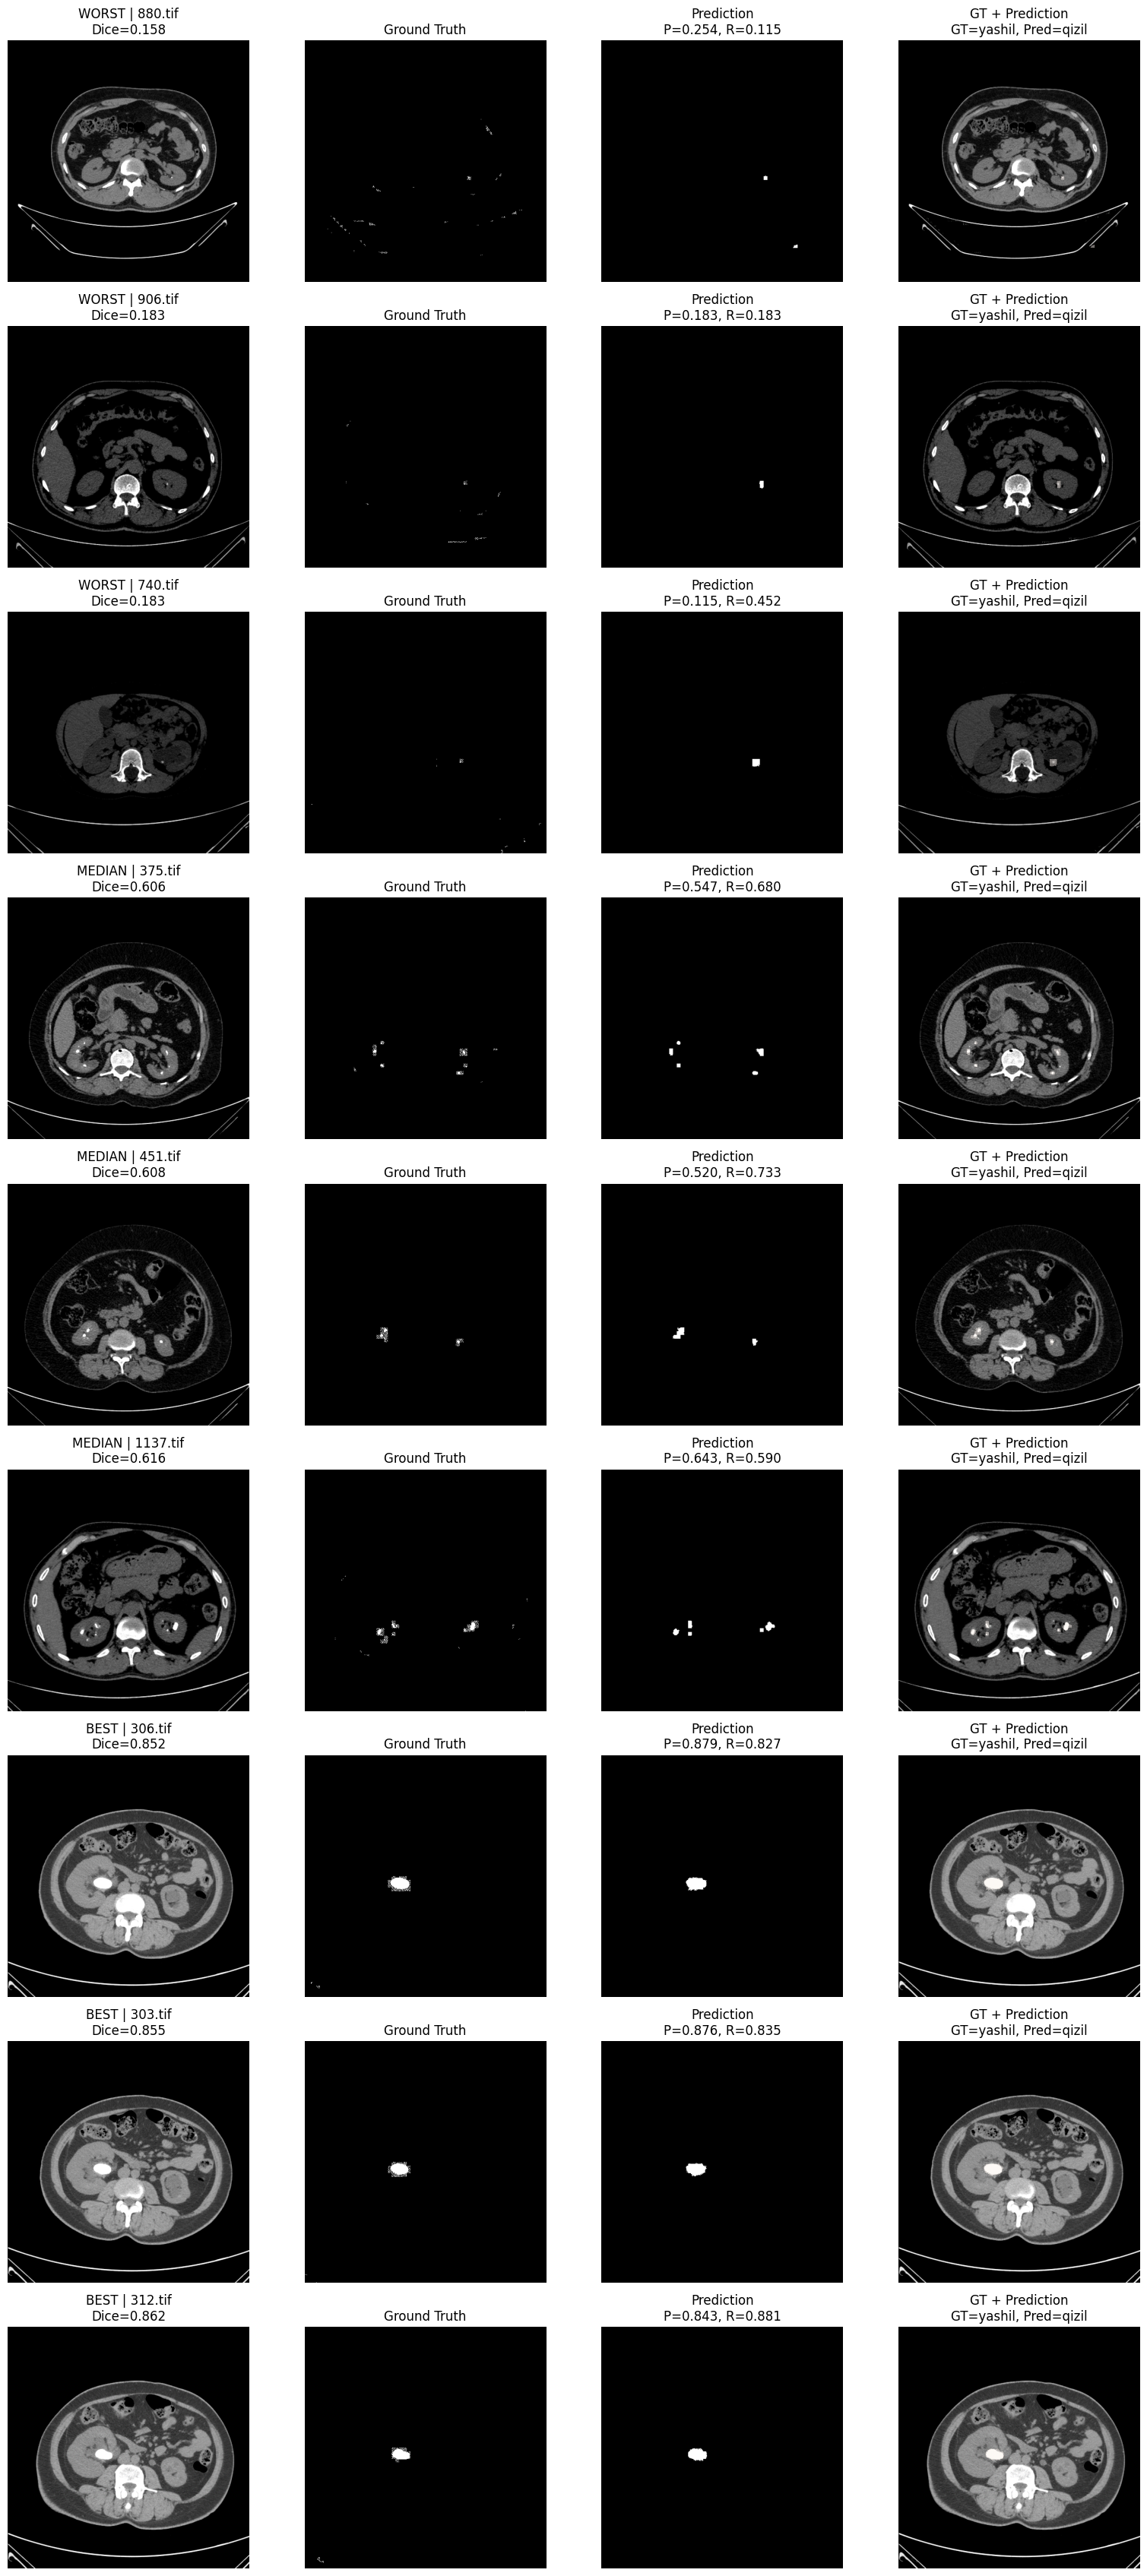


Figure saqlandi: results/figures/best_median_worst_cases.png


In [46]:
# ============================================================
# BEST / MEDIAN / WORST TEST CASE VISUALIZATION - TUZATILGAN
#
# MUHIM:
# Mask pathni image pathdan taxmin qilmaymiz.
# data/splits/test.csv ichidagi haqiqiy image-mask juftligidan
# foydalanamiz.
#
# Ko'rsatiladi:
# 1. Original CT
# 2. Ground Truth
# 3. Prediction
# 4. Overlay
# ============================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image
from scipy import ndimage

sys.path.append("src")

from common import load_config, resolve_path
from dataset import KidneyStoneDataset
from model import build_model


# ============================================================
# 1-BO'LIM:
# Config va final parametrlarni yuklash
# ============================================================

cfg = load_config(
    "configs/config.yaml"
)

FINAL_THRESHOLD = 0.993
MIN_COMPONENT_PIXELS = 50

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 2-BO'LIM:
# Final best modelni yuklash
# ============================================================

model = build_model(cfg).to(device)

checkpoint = torch.load(
    "models/best_2d_unet.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model"]
)

model.eval()

print("Model yuklandi.")


# ============================================================
# 3-BO'LIM:
# Predictiondagi juda kichik componentlarni olib tashlash
# ============================================================

def remove_small_components(
    mask,
    min_pixels
):

    mask = mask.astype(bool)

    labeled, n = ndimage.label(mask)

    cleaned = np.zeros_like(
        mask,
        dtype=np.uint8
    )

    for component_id in range(
        1,
        n + 1
    ):

        component = (
            labeled == component_id
        )

        area = int(
            component.sum()
        )

        if area >= min_pixels:
            cleaned[component] = 1

    return cleaned


# ============================================================
# 4-BO'LIM:
# Test metricsni yuklash
# ============================================================

metrics_path = Path(
    "results/metrics/test_metrics.csv"
)

metrics_df = pd.read_csv(
    metrics_path
)

metrics_df = metrics_df.sort_values(
    "dice"
).reset_index(drop=True)


# ============================================================
# 5-BO'LIM:
# TEST SPLIT ichidagi haqiqiy image-mask juftliklarini o'qish
# ============================================================

splits_dir = resolve_path(
    cfg["data"]["splits_dir"]
)

test_split_path = (
    splits_dir / "test.csv"
)

test_pairs = pd.read_csv(
    test_split_path
)

print("\nTest split columns:")
print(
    test_pairs.columns.tolist()
)

print("\nBirinchi test pair:")
print(
    test_pairs.head(1).to_string(
        index=False
    )
)


# ============================================================
# 6-BO'LIM:
# Mask column nomini avtomatik aniqlash
#
# Bizning projectda odatda "mask" bo'ladi.
# Lekin kod robust bo'lishi uchun bir nechta variantni tekshiradi.
# ============================================================

possible_mask_columns = [
    "mask",
    "label",
    "mask_path",
    "label_path",
    "target"
]

MASK_COLUMN = None

for col in possible_mask_columns:

    if col in test_pairs.columns:
        MASK_COLUMN = col
        break


if MASK_COLUMN is None:

    raise RuntimeError(
        "test.csv ichidan mask column topilmadi. "
        f"Columns: {test_pairs.columns.tolist()}"
    )


print(
    "\nMask column:",
    MASK_COLUMN
)


# ============================================================
# 7-BO'LIM:
# Image path -> haqiqiy mask path dictionary
# ============================================================

image_to_mask = dict(
    zip(
        test_pairs["image"].astype(str),
        test_pairs[MASK_COLUMN].astype(str)
    )
)

print(
    "Image-mask mapping soni:",
    len(image_to_mask)
)


# ============================================================
# 8-BO'LIM:
# Worst / Median / Best case'larni tanlash
# ============================================================

worst = metrics_df.head(3)

middle = len(metrics_df) // 2

median_cases = metrics_df.iloc[
    middle - 1:
    middle + 2
]

best = metrics_df.tail(3)


selected = pd.concat(
    [
        worst.assign(group="WORST"),
        median_cases.assign(group="MEDIAN"),
        best.assign(group="BEST"),
    ],
    ignore_index=True
)


print("\n===== TANLANGAN CASE'LAR =====")

print(
    selected[
        [
            "group",
            "image",
            "dice",
            "precision",
            "recall"
        ]
    ].to_string(index=False)
)


# ============================================================
# 9-BO'LIM:
# Bitta CT uchun prediction funksiyasi
# ============================================================

def predict_one(
    image_path
):

    image_path = str(
        image_path
    )

    # --------------------------------------------------------
    # MUHIM:
    # Endi /image/ -> /mask/ deb almashtirmaymiz.
    #
    # test.csv ichidagi haqiqiy mask pathni olamiz.
    # --------------------------------------------------------

    if image_path not in image_to_mask:

        raise KeyError(
            f"Test splitda image topilmadi:\n{image_path}"
        )

    mask_path = image_to_mask[
        image_path
    ]


    # --------------------------------------------------------
    # Image va mask fayllari haqiqatan mavjudligini tekshirish
    # --------------------------------------------------------

    if not Path(image_path).exists():

        raise FileNotFoundError(
            f"Image topilmadi:\n{image_path}"
        )

    if not Path(mask_path).exists():

        raise FileNotFoundError(
            f"Mask topilmadi:\n{mask_path}"
        )


    # --------------------------------------------------------
    # Trainingda ishlatgan preprocessingni aynan qayta ishlatamiz
    # --------------------------------------------------------

    one_df = pd.DataFrame(
        [
            {
                "image": image_path,
                "mask": mask_path
            }
        ]
    )

    dataset = KidneyStoneDataset(
        one_df,
        image_size=tuple(
            cfg["data"]["image_size"]
        ),
        augment=False
    )

    item = dataset[0]


    x = item["image"][
        None
    ].to(device)


    target = (
        item["mask"][0]
        .numpy()
        > 0.5
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # Model prediction
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(x)

        probability = torch.sigmoid(
            logits
        )[0, 0].cpu().numpy()


    # --------------------------------------------------------
    # Validation orqali tanlangan threshold
    # --------------------------------------------------------

    pred = (
        probability
        >= FINAL_THRESHOLD
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # Validation orqali tanlangan postprocessing
    # --------------------------------------------------------

    pred = remove_small_components(
        pred,
        MIN_COMPONENT_PIXELS
    )


    # --------------------------------------------------------
    # Original CT visualization uchun
    # --------------------------------------------------------

    original = np.asarray(
        Image.open(
            image_path
        )
    )

    if original.ndim == 3:

        original = original[
            ..., :3
        ].mean(axis=2)


    return (
        original,
        target,
        pred,
        probability,
        mask_path
    )


# ============================================================
# 10-BO'LIM:
# 9 case × 4 column
#
# Column:
# 1. Original CT
# 2. Ground Truth
# 3. Prediction
# 4. Overlay
# ============================================================

fig, axes = plt.subplots(
    nrows=len(selected),
    ncols=4,
    figsize=(16, 34)
)


for row_idx, row in selected.iterrows():

    (
        original,
        target,
        pred,
        probability,
        mask_path
    ) = predict_one(
        row["image"]
    )


    # --------------------------------------------------------
    # ORIGINAL CT
    # --------------------------------------------------------

    axes[row_idx, 0].imshow(
        original,
        cmap="gray"
    )

    axes[row_idx, 0].set_title(
        f"{row['group']} | "
        f"{Path(row['image']).name}\n"
        f"Dice={row['dice']:.3f}"
    )


    # --------------------------------------------------------
    # GROUND TRUTH
    # --------------------------------------------------------

    axes[row_idx, 1].imshow(
        target,
        cmap="gray"
    )

    axes[row_idx, 1].set_title(
        "Ground Truth"
    )


    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    axes[row_idx, 2].imshow(
        pred,
        cmap="gray"
    )

    axes[row_idx, 2].set_title(
        f"Prediction\n"
        f"P={row['precision']:.3f}, "
        f"R={row['recall']:.3f}"
    )


    # --------------------------------------------------------
    # OVERLAY
    #
    # Original CT ustiga GT va Predictionni qo'yamiz.
    # --------------------------------------------------------

    axes[row_idx, 3].imshow(
        original,
        cmap="gray"
    )


    gt_overlay = np.ma.masked_where(
        target == 0,
        target
    )

    pred_overlay = np.ma.masked_where(
        pred == 0,
        pred
    )


    axes[row_idx, 3].imshow(
        gt_overlay,
        alpha=0.45,
        cmap="Greens"
    )

    axes[row_idx, 3].imshow(
        pred_overlay,
        alpha=0.45,
        cmap="Reds"
    )


    axes[row_idx, 3].set_title(
        "GT + Prediction\n"
        "GT=yashil, Pred=qizil"
    )


    for col in range(4):

        axes[row_idx, col].axis(
            "off"
        )


plt.tight_layout()


# ============================================================
# 11-BO'LIM:
# Figureni saqlash
# ============================================================

output_path = Path(
    "results/figures/"
    "best_median_worst_cases.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(
    "\nFigure saqlandi:",
    output_path
)

In [47]:
%%writefile src/predict.py

# ============================================================
# KIDNEY STONE SEGMENTATION - FINAL PREDICTION
#
# Bu skript yangi 2D CT TIF rasmga prediction qiladi.
#
# Final pipeline:
#   1. CT rasmni o'qish
#   2. Trainingdagi preprocessingni qo'llash
#   3. 2D U-Net prediction
#   4. Sigmoid probability
#   5. Threshold = config.yaml
#   6. Kichik connected componentlarni olib tashlash
#   7. Mask, overlay va probability mapni saqlash
#
# MUHIM:
# KSSD2025 datasetida fizik pixel spacing ishlatilmaydi.
# Shu sabab area pixel birlikda hisoblanadi.
# ============================================================

import argparse
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image
from scipy import ndimage

sys.path.append(str(Path(__file__).resolve().parent))

from common import load_config, resolve_path
from model import build_model


# ============================================================
# 1-BO'LIM:
# Rasmni preprocessing qilish
#
# Trainingdagi dataset.py bilan mos:
# - grayscale
# - 0.5 / 99.5 percentile clipping
# - 0..1 normalization
# - configdagi image_size ga resize
# ============================================================

def preprocess_image(
    image_path,
    image_size
):

    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Rasm topilmadi: {image_path}"
        )

    # --------------------------------------------------------
    # TIF rasmni ochamiz
    # --------------------------------------------------------

    image = np.asarray(
        Image.open(image_path)
    )


    # --------------------------------------------------------
    # Agar RGB bo'lsa grayscale qilamiz
    # --------------------------------------------------------

    if image.ndim == 3:

        image = image[
            ..., :3
        ].mean(axis=2)


    image = image.astype(
        np.float32
    )


    # --------------------------------------------------------
    # Percentile clipping
    # Training preprocessing bilan bir xil.
    # --------------------------------------------------------

    low = np.percentile(
        image,
        0.5
    )

    high = np.percentile(
        image,
        99.5
    )


    if high > low:

        image = np.clip(
            image,
            low,
            high
        )

        image = (
            image - low
        ) / (
            high - low
        )

    else:

        image = np.zeros_like(
            image,
            dtype=np.float32
        )


    # --------------------------------------------------------
    # PIL resize uchun 0..255 ga o'tkazamiz
    # --------------------------------------------------------

    image_uint8 = (
        image * 255
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )


    # image_size = [512, 512]
    height = int(
        image_size[0]
    )

    width = int(
        image_size[1]
    )


    resized = Image.fromarray(
        image_uint8
    ).resize(
        (width, height),
        resample=Image.Resampling.BILINEAR
    )


    resized = np.asarray(
        resized
    ).astype(
        np.float32
    ) / 255.0


    # --------------------------------------------------------
    # PyTorch format:
    #
    # H × W
    #   ↓
    # 1 × H × W
    #   ↓
    # batch uchun
    # 1 × 1 × H × W
    # --------------------------------------------------------

    tensor = torch.from_numpy(
        resized
    ).float()

    tensor = tensor.unsqueeze(
        0
    ).unsqueeze(
        0
    )


    return (
        tensor,
        image,
        resized
    )


# ============================================================
# 2-BO'LIM:
# Kichik connected componentlarni olib tashlash
# ============================================================

def remove_small_components(
    mask,
    min_pixels
):

    mask = mask.astype(
        bool
    )

    labeled, n = ndimage.label(
        mask
    )

    cleaned = np.zeros_like(
        mask,
        dtype=np.uint8
    )


    for component_id in range(
        1,
        n + 1
    ):

        component = (
            labeled == component_id
        )

        area = int(
            component.sum()
        )


        if area >= min_pixels:

            cleaned[
                component
            ] = 1


    return cleaned


# ============================================================
# 3-BO'LIM:
# Final prediction funksiyasi
# ============================================================

def predict_image(
    image_path,
    config_path
):

    # --------------------------------------------------------
    # Config
    # --------------------------------------------------------

    cfg = load_config(
        config_path
    )


    image_size = tuple(
        int(x)
        for x in cfg["data"]["image_size"]
    )


    threshold = float(
        cfg["training"]["threshold"]
    )


    min_component_pixels = int(
        cfg["postprocess"][
            "min_component_pixels"
        ]
    )


    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print(
        "Device:",
        device
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = build_model(
        cfg
    ).to(
        device
    )


    model_path = resolve_path(
        cfg["paths"]["best_model"]
    )


    checkpoint = torch.load(
        model_path,
        map_location=device
    )


    model.load_state_dict(
        checkpoint["model"]
    )

    model.eval()


    print(
        "Model:",
        model_path
    )

    print(
        "Threshold:",
        threshold
    )

    print(
        "Min component pixels:",
        min_component_pixels
    )


    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    (
        tensor,
        original_normalized,
        resized
    ) = preprocess_image(
        image_path,
        image_size
    )


    tensor = tensor.to(
        device
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    with torch.no_grad():

        logits = model(
            tensor
        )

        probability = torch.sigmoid(
            logits
        )[0, 0].cpu().numpy()


    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    raw_mask = (
        probability
        >= threshold
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # Postprocessing
    # --------------------------------------------------------

    final_mask = remove_small_components(
        raw_mask,
        min_component_pixels
    )


    # --------------------------------------------------------
    # Quantitative analysis
    # --------------------------------------------------------

    predicted_area_pixels = int(
        final_mask.sum()
    )


    labeled, n_regions = ndimage.label(
        final_mask
    )


    region_areas = []


    for component_id in range(
        1,
        n_regions + 1
    ):

        area = int(
            (
                labeled == component_id
            ).sum()
        )

        region_areas.append(
            area
        )


    region_areas = sorted(
        region_areas,
        reverse=True
    )


    result = {
        "probability": probability,
        "raw_mask": raw_mask,
        "final_mask": final_mask,
        "predicted_area_pixels":
            predicted_area_pixels,
        "estimated_connected_regions":
            int(n_regions),
        "region_areas_pixels":
            region_areas,
        "threshold":
            threshold,
        "min_component_pixels":
            min_component_pixels,
        "resized_image":
            resized
    }


    return result


# ============================================================
# 4-BO'LIM:
# Prediction natijalarini saqlash
# ============================================================

def save_prediction(
    image_path,
    result,
    output_dir
):

    image_path = Path(
        image_path
    )

    output_dir = Path(
        output_dir
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    stem = image_path.stem


    # --------------------------------------------------------
    # Final binary mask
    # --------------------------------------------------------

    mask_path = (
        output_dir
        /
        f"{stem}_mask.png"
    )


    Image.fromarray(
        (
            result["final_mask"]
            * 255
        ).astype(
            np.uint8
        )
    ).save(
        mask_path
    )


    # --------------------------------------------------------
    # Probability map
    # --------------------------------------------------------

    probability_path = (
        output_dir
        /
        f"{stem}_probability.png"
    )


    probability_uint8 = (
        result["probability"]
        * 255
    ).clip(
        0,
        255
    ).astype(
        np.uint8
    )


    Image.fromarray(
        probability_uint8
    ).save(
        probability_path
    )


    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    figure_path = (
        output_dir
        /
        f"{stem}_prediction.png"
    )


    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 5)
    )


    # Original
    axes[0].imshow(
        result["resized_image"],
        cmap="gray"
    )

    axes[0].set_title(
        "CT"
    )


    # Probability
    im = axes[1].imshow(
        result["probability"],
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        "Probability"
    )

    plt.colorbar(
        im,
        ax=axes[1],
        fraction=0.046,
        pad=0.04
    )


    # Final mask
    axes[2].imshow(
        result["final_mask"],
        cmap="gray"
    )

    axes[2].set_title(
        "Final mask"
    )


    # Overlay
    axes[3].imshow(
        result["resized_image"],
        cmap="gray"
    )


    overlay = np.ma.masked_where(
        result["final_mask"] == 0,
        result["final_mask"]
    )


    axes[3].imshow(
        overlay,
        alpha=0.50
    )


    axes[3].set_title(
        "Stone overlay"
    )


    for ax in axes:
        ax.axis(
            "off"
        )


    plt.tight_layout()

    plt.savefig(
        figure_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(
        fig
    )


    return {
        "mask_path": mask_path,
        "probability_path":
            probability_path,
        "figure_path":
            figure_path
    }


# ============================================================
# 5-BO'LIM:
# Terminal orqali ishga tushirish
# ============================================================

def main():

    parser = argparse.ArgumentParser(
        description=(
            "KSSD2025 Kidney Stone "
            "Segmentation Prediction"
        )
    )


    parser.add_argument(
        "--config",
        type=str,
        default="configs/config.yaml"
    )


    parser.add_argument(
        "--image",
        type=str,
        required=True,
        help="Prediction qilinadigan TIF rasm"
    )


    parser.add_argument(
        "--output_dir",
        type=str,
        default=None
    )


    args = parser.parse_args()


    cfg = load_config(
        args.config
    )


    if args.output_dir is None:

        output_dir = resolve_path(
            cfg["paths"]["prediction_dir"]
        )

    else:

        output_dir = Path(
            args.output_dir
        )


    result = predict_image(
        args.image,
        args.config
    )


    files = save_prediction(
        args.image,
        result,
        output_dir
    )


    # ========================================================
    # FINAL OUTPUT
    # ========================================================

    print(
        "\n===== PREDICTION RESULT ====="
    )

    print(
        "Predicted stone area:",
        result["predicted_area_pixels"],
        "pixels"
    )


    print(
        "Estimated connected regions:",
        result[
            "estimated_connected_regions"
        ]
    )


    print(
        "Region areas:",
        result[
            "region_areas_pixels"
        ]
    )


    print(
        "\nMask:",
        files["mask_path"]
    )


    print(
        "Probability:",
        files["probability_path"]
    )


    print(
        "Figure:",
        files["figure_path"]
    )


    print(
        "\nNOTE:"
    )

    print(
        "Area pixel birlikda berildi. "
        "KSSD2025 pipeline fizik pixel spacing "
        "ishlatmagani uchun mm² hisoblanmaydi."
    )


if __name__ == "__main__":
    main()

Overwriting src/predict.py


In [48]:
!python src/predict.py \
    --config configs/config.yaml \
    --image data/raw/kssd2025/data/image/312.tif

Device: cuda
Model: /content/drive/MyDrive/kidney_stone_project_2/models/best_2d_unet.pth
Threshold: 0.993
Min component pixels: 50

===== PREDICTION RESULT =====
Predicted stone area: 816 pixels
Estimated connected regions: 1
Region areas: [816]

Mask: /content/drive/MyDrive/kidney_stone_project_2/results/predictions/312_mask.png
Probability: /content/drive/MyDrive/kidney_stone_project_2/results/predictions/312_probability.png
Figure: /content/drive/MyDrive/kidney_stone_project_2/results/predictions/312_prediction.png

NOTE:
Area pixel birlikda berildi. KSSD2025 pipeline fizik pixel spacing ishlatmagani uchun mm² hisoblanmaydi.


In [49]:
%%writefile app/app.py

# ============================================================
# KIDNEY STONE SEGMENTATION - GRADIO FINAL APP
#
# Bu dastur:
# 1. CT TIF rasmni qabul qiladi
# 2. Final 2D U-Net model orqali segmentation qiladi
# 3. threshold = config.yaml dagi final qiymatni ishlatadi
# 4. Kichik connected componentlarni olib tashlaydi
# 5. CT, probability map, mask va overlayni ko'rsatadi
# 6. Stone pixel area va connected regionlarni chiqaradi
#
# MUHIM:
# - Model KSSD2025 2D TIF datasetida train qilingan.
# - Fizik pixel spacing mavjud emas.
# - Shu sabab mm² yoki mm³ hisoblanmaydi.
# - Bu dastur klinik tashxis vositasi emas.
# ============================================================

import os
import sys
from pathlib import Path

import gradio as gr
import numpy as np
import torch

from PIL import Image
from scipy import ndimage


# ============================================================
# 1-BO'LIM:
# Project pathlarini sozlash
# ============================================================

PROJECT_ROOT = Path(
    __file__
).resolve().parents[1]

SRC_DIR = (
    PROJECT_ROOT / "src"
)

sys.path.insert(
    0,
    str(SRC_DIR)
)

# Relative pathlar har doim project rootdan ishlashi uchun
os.chdir(
    PROJECT_ROOT
)


# ============================================================
# 2-BO'LIM:
# Project funksiyalarini import qilish
# ============================================================

from common import (
    load_config,
    resolve_path
)

from model import build_model

from predict import (
    preprocess_image,
    remove_small_components
)


# ============================================================
# 3-BO'LIM:
# Configni yuklash
# ============================================================

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "config.yaml"
)

cfg = load_config(
    str(CONFIG_PATH)
)


IMAGE_SIZE = tuple(
    int(x)
    for x in cfg["data"]["image_size"]
)

THRESHOLD = float(
    cfg["training"]["threshold"]
)

MIN_COMPONENT_PIXELS = int(
    cfg["postprocess"][
        "min_component_pixels"
    ]
)


# ============================================================
# 4-BO'LIM:
# GPU / CPU aniqlash
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)


# ============================================================
# 5-BO'LIM:
# Modelni FAQAT BIR MARTA yuklash
#
# Har predictionda modelni qayta yuklamaymiz.
# Shu sabab Gradio tezroq ishlaydi.
# ============================================================

model = build_model(
    cfg
).to(
    device
)


model_path = resolve_path(
    cfg["paths"]["best_model"]
)


checkpoint = torch.load(
    model_path,
    map_location=device
)


model.load_state_dict(
    checkpoint["model"]
)

model.eval()


print(
    "Model yuklandi:",
    model_path
)

print(
    "Threshold:",
    THRESHOLD
)

print(
    "Min component pixels:",
    MIN_COMPONENT_PIXELS
)


# ============================================================
# 6-BO'LIM:
# Float image -> uint8
# ============================================================

def to_uint8(image):

    image = np.asarray(
        image,
        dtype=np.float32
    )

    image = np.clip(
        image,
        0,
        1
    )

    return (
        image * 255
    ).astype(
        np.uint8
    )


# ============================================================
# 7-BO'LIM:
# Overlay yaratish
#
# Predicted stone region qizil overlay bilan ko'rsatiladi.
# ============================================================

def create_overlay(
    image,
    mask
):

    base = to_uint8(
        image
    )

    # Grayscale -> RGB
    rgb = np.stack(
        [
            base,
            base,
            base
        ],
        axis=-1
    ).astype(
        np.float32
    )


    mask_bool = (
        mask > 0
    )


    # Stone region uchun qizil layer
    red_layer = np.zeros_like(
        rgb
    )

    red_layer[
        ...,
        0
    ] = 255


    # Faqat mask bor joyda overlay
    rgb[
        mask_bool
    ] = (
        0.55
        * rgb[
            mask_bool
        ]
        +
        0.45
        * red_layer[
            mask_bool
        ]
    )


    return np.clip(
        rgb,
        0,
        255
    ).astype(
        np.uint8
    )


# ============================================================
# 8-BO'LIM:
# Connected region statistikasi
# ============================================================

def get_region_stats(
    mask
):

    labeled, n_regions = (
        ndimage.label(
            mask
        )
    )

    region_areas = []


    for component_id in range(
        1,
        n_regions + 1
    ):

        area = int(
            (
                labeled
                == component_id
            ).sum()
        )

        region_areas.append(
            area
        )


    region_areas = sorted(
        region_areas,
        reverse=True
    )


    return (
        int(n_regions),
        region_areas
    )


# ============================================================
# 9-BO'LIM:
# Asosiy Gradio prediction funksiyasi
# ============================================================

def segment_kidney_stone(
    image_path
):

    # --------------------------------------------------------
    # Upload qilinmagan bo'lsa
    # --------------------------------------------------------

    if image_path is None:

        return (
            None,
            None,
            None,
            None,
            "Rasm yuklanmadi."
        )


    # --------------------------------------------------------
    # Preprocessing
    # --------------------------------------------------------

    try:

        (
            tensor,
            original_normalized,
            resized
        ) = preprocess_image(
            image_path,
            IMAGE_SIZE
        )

    except Exception as e:

        return (
            None,
            None,
            None,
            None,
            f"Rasmni o'qishda xato: {e}"
        )


    tensor = tensor.to(
        device
    )


    # --------------------------------------------------------
    # Model inference
    # --------------------------------------------------------

    try:

        with torch.no_grad():

            logits = model(
                tensor
            )

            probability = torch.sigmoid(
                logits
            )[0, 0].cpu().numpy()

    except Exception as e:

        return (
            None,
            None,
            None,
            None,
            f"Prediction xatosi: {e}"
        )


    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    raw_mask = (
        probability
        >= THRESHOLD
    ).astype(
        np.uint8
    )


    # --------------------------------------------------------
    # Final postprocessing
    # --------------------------------------------------------

    final_mask = remove_small_components(
        raw_mask,
        MIN_COMPONENT_PIXELS
    )


    # --------------------------------------------------------
    # Stone area
    # --------------------------------------------------------

    stone_area = int(
        final_mask.sum()
    )


    # --------------------------------------------------------
    # Connected regions
    # --------------------------------------------------------

    (
        n_regions,
        region_areas
    ) = get_region_stats(
        final_mask
    )


    # --------------------------------------------------------
    # Visualizationlar
    # --------------------------------------------------------

    ct_image = to_uint8(
        resized
    )


    probability_image = (
        np.clip(
            probability,
            0,
            1
        )
        * 255
    ).astype(
        np.uint8
    )


    mask_image = (
        final_mask
        * 255
    ).astype(
        np.uint8
    )


    overlay_image = create_overlay(
        resized,
        final_mask
    )


    # --------------------------------------------------------
    # Natija matni
    # --------------------------------------------------------

    if stone_area == 0:

        detection_text = (
            "Final threshold va postprocessingdan "
            "keyin segmentlangan region topilmadi."
        )

    else:

        detection_text = (
            "Segmentlangan kidney-stone region "
            "mavjud."
        )


    regions_text = (
        ", ".join(
            str(x)
            for x in region_areas
        )
        if region_areas
        else "0"
    )


    result_text = f"""
### Segmentation natijasi

**Holat:** {detection_text}

**Predicted stone area:** `{stone_area}` pixel

**Estimated connected regions:** `{n_regions}`

**Region areas:** `{regions_text}` pixel

**Threshold:** `{THRESHOLD}`

**Minimum component size:** `{MIN_COMPONENT_PIXELS}` pixel

---

**Eslatma:** `Estimated connected regions` klinik jihatdan
aniq kidney-stone soni degani emas.

KSSD2025 pipeline fizik pixel spacing ishlatmagani sabab
maydon `mm²` emas, **pixel** birlikda beriladi.

Bu model tadqiqot va ta'lim maqsadida yaratilgan,
klinik tashxis o'rnini bosmaydi.
"""


    return (
        ct_image,
        probability_image,
        mask_image,
        overlay_image,
        result_text
    )


# ============================================================
# 10-BO'LIM:
# Gradio interfeys
# ============================================================

with gr.Blocks(
    title="Kidney Stone Segmentation"
) as demo:


    gr.Markdown(
        """
# Kidney Stone Segmentation

2D CT tasvirlarda kidney-stone hududini
U-Net yordamida segmentatsiya qilish.

**Final model:** 2D U-Net
**Dataset:** KSSD2025
**Input:** 512 × 512
**Threshold:** 0.993
**Postprocessing:** `< 50 pixel` componentlar olib tashlanadi
"""
    )


    with gr.Row():

        with gr.Column():

            input_image = gr.Image(
                type="filepath",
                label="CT TIF rasmni yuklang"
            )

            predict_button = gr.Button(
                "Segmentation qilish",
                variant="primary"
            )

            clear_button = gr.ClearButton(
                value="Tozalash"
            )


        with gr.Column():

            result_text = gr.Markdown(
                value=(
                    "CT rasm yuklang va "
                    "**Segmentation qilish** "
                    "tugmasini bosing."
                )
            )


    gr.Markdown(
        "## Visualization"
    )


    with gr.Row():

        ct_output = gr.Image(
            label="Preprocessed CT"
        )

        probability_output = gr.Image(
            label="Probability map"
        )


    with gr.Row():

        mask_output = gr.Image(
            label="Final segmentation mask"
        )

        overlay_output = gr.Image(
            label="Stone overlay"
        )


    # ========================================================
    # Button action
    # ========================================================

    predict_button.click(
        fn=segment_kidney_stone,
        inputs=[
            input_image
        ],
        outputs=[
            ct_output,
            probability_output,
            mask_output,
            overlay_output,
            result_text
        ]
    )


    clear_button.add(
        [
            input_image,
            ct_output,
            probability_output,
            mask_output,
            overlay_output,
            result_text
        ]
    )


# ============================================================
# 11-BO'LIM:
# Appni ishga tushirish
#
# share=True:
# Google Colab uchun public Gradio link beradi.
# ============================================================

if __name__ == "__main__":

    demo.launch(
        share=True,
        debug=True
    )

Overwriting app/app.py


In [50]:
!pip install -q gradio

In [57]:
!python app/app.py

python3: can't open file '/content/drive/MyDrive/app/app.py': [Errno 2] No such file or directory


In [53]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [54]:
!zip -r kidney_stone_project_2_FINAL.zip kidney_stone_project_2 \
    -x "*/__pycache__/*" \
       "*/.ipynb_checkpoints/*"

  adding: kidney_stone_project_2/ (stored 0%)
  adding: kidney_stone_project_2/requirements.txt (deflated 30%)
  adding: kidney_stone_project_2/README.md (deflated 57%)
  adding: kidney_stone_project_2/PROJECT_STRUCTURE.md (deflated 59%)
  adding: kidney_stone_project_2/run_pipeline.py (deflated 54%)
  adding: kidney_stone_project_2/.gitignore (deflated 31%)
  adding: kidney_stone_project_2/configs/ (stored 0%)
  adding: kidney_stone_project_2/configs/config.yaml (deflated 51%)
  adding: kidney_stone_project_2/results/ (stored 0%)
  adding: kidney_stone_project_2/results/metrics/ (stored 0%)
  adding: kidney_stone_project_2/results/metrics/.gitkeep (stored 0%)
  adding: kidney_stone_project_2/results/metrics/training_history.csv (deflated 47%)
  adding: kidney_stone_project_2/results/metrics/test_metrics.csv (deflated 70%)
  adding: kidney_stone_project_2/results/metrics/test_summary.json (deflated 35%)
  adding: kidney_stone_project_2/results/figures/ (stored 0%)
  adding: kidney_ston

In [55]:
!ls -lh /content/drive/MyDrive/kidney_stone_project_2_FINAL.zip

-rw------- 1 root root 87M Sep  1 04:59 /content/drive/MyDrive/kidney_stone_project_2_FINAL.zip


In [58]:
%cd /content/drive/MyDrive/kidney_stone_project_2

/content/drive/MyDrive/kidney_stone_project_2


In [59]:
!python app/app.py

Device: cuda
Model yuklandi: /content/drive/MyDrive/kidney_stone_project_2/models/best_2d_unet.pth
Threshold: 0.993
Min component pixels: 50
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://bb307576ca19e118a7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/gradio/blocks.py", line 3564, in block_thread
    time.sleep(0.1)
    ~~~~~~~~~~^^^^^
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/drive/MyDrive/kidney_stone_project_2/app/app.py", line 664, in <module>
    demo.launch(
    ~~~~~~~~~~~^
        share=True,
        

In [61]:
%%writefile src/evaluate.py

# ============================================================
# KIDNEY STONE SEGMENTATION - FINAL EVALUATION
#
# Bu skript final modelni TEST datasetda baholaydi.
#
# Hisoblanadigan asosiy metrikalar:
#
# 1. Mean per-image Dice
# 2. Mean per-image IoU
# 3. Mean per-image Precision
# 4. Mean per-image Recall
#
# 5. Global Dice
# 6. Global IoU
# 7. Global Precision
# 8. Global Recall
#
# 9. Mean absolute area error (pixel)
#
# MUHIM:
# - threshold validation set orqali tanlangan.
# - min_component_pixels validation set orqali tanlangan.
# - TEST set parametr tanlash uchun ishlatilmaydi.
#
# KSSD2025 fizik pixel spacing bermagani sabab:
# mm² yoki mm³ hisoblanmaydi.
#
# "Stone count" metric olib tashlangan.
# Connected componentlar bu datasetda klinik stone count
# sifatida ishonchli emas.
# ============================================================


import argparse
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from scipy import ndimage
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ============================================================
# 1-BO'LIM:
# src papkani Python pathga qo'shamiz
# ============================================================

SRC_DIR = Path(__file__).resolve().parent

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR)
    )


from common import (
    load_config,
    resolve_path
)

from dataset import KidneyStoneDataset

from model import build_model


# ============================================================
# 2-BO'LIM:
# Kichik connected componentlarni olib tashlash
#
# Faqat PREDICTION maskga qo'llanadi.
# Ground Truth mask o'zgartirilmaydi.
# ============================================================

def remove_small_components(
    mask,
    min_pixels
):

    mask = mask.astype(
        bool
    )

    labeled, n_components = ndimage.label(
        mask
    )

    cleaned = np.zeros_like(
        mask,
        dtype=np.uint8
    )


    for component_id in range(
        1,
        n_components + 1
    ):

        component = (
            labeled == component_id
        )

        area = int(
            component.sum()
        )


        if area >= min_pixels:

            cleaned[
                component
            ] = 1


    return cleaned


# ============================================================
# 3-BO'LIM:
# Bitta image uchun TP, FP, FN asosida metric hisoblash
# ============================================================

def calculate_metrics(
    target,
    prediction
):

    target = target.astype(
        bool
    )

    prediction = prediction.astype(
        bool
    )


    tp = int(
        np.logical_and(
            prediction,
            target
        ).sum()
    )


    fp = int(
        np.logical_and(
            prediction,
            np.logical_not(target)
        ).sum()
    )


    fn = int(
        np.logical_and(
            np.logical_not(prediction),
            target
        ).sum()
    )


    eps = 1e-7


    dice = (
        2 * tp + eps
    ) / (
        2 * tp
        + fp
        + fn
        + eps
    )


    iou = (
        tp + eps
    ) / (
        tp
        + fp
        + fn
        + eps
    )


    precision = (
        tp + eps
    ) / (
        tp
        + fp
        + eps
    )


    recall = (
        tp + eps
    ) / (
        tp
        + fn
        + eps
    )


    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
    }


# ============================================================
# 4-BO'LIM:
# Asosiy evaluation funksiyasi
# ============================================================

def evaluate(
    config_path
):

    # --------------------------------------------------------
    # Config
    # --------------------------------------------------------

    cfg = load_config(
        config_path
    )


    threshold = float(
        cfg["training"]["threshold"]
    )


    min_component_pixels = int(
        cfg["postprocess"][
            "min_component_pixels"
        ]
    )


    image_size = tuple(
        int(x)
        for x in cfg["data"]["image_size"]
    )


    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )


    print(
        "Device:",
        device
    )

    print(
        "Threshold:",
        threshold
    )

    print(
        "Min component pixels:",
        min_component_pixels
    )


    # ========================================================
    # 5-BO'LIM:
    # Test splitni yuklash
    # ========================================================

    splits_dir = resolve_path(
        cfg["data"]["splits_dir"]
    )


    test_csv_path = (
        splits_dir
        / "test.csv"
    )


    test_df = pd.read_csv(
        test_csv_path
    )


    print(
        "Test images:",
        len(test_df)
    )


    # ========================================================
    # 6-BO'LIM:
    # Dataset va DataLoader
    #
    # batch_size=1:
    # har bir image uchun alohida metric yozish oson bo'ladi.
    # ========================================================

    test_dataset = KidneyStoneDataset(
        test_df,
        image_size=image_size,
        augment=False
    )


    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=int(
            cfg["training"].get(
                "num_workers",
                2
            )
        ),
        pin_memory=(
            device.type == "cuda"
        )
    )


    # ========================================================
    # 7-BO'LIM:
    # Final best modelni yuklash
    # ========================================================

    model = build_model(
        cfg
    ).to(
        device
    )


    model_path = resolve_path(
        cfg["paths"]["best_model"]
    )


    checkpoint = torch.load(
        model_path,
        map_location=device
    )


    model.load_state_dict(
        checkpoint["model"]
    )

    model.eval()


    print(
        "Model:",
        model_path
    )


    # ========================================================
    # 8-BO'LIM:
    # Test prediction
    # ========================================================

    rows = []


    # Global metric uchun yig'iladi
    total_tp = 0
    total_fp = 0
    total_fn = 0


    with torch.no_grad():

        for index, batch in enumerate(
            tqdm(
                test_loader,
                desc="Test"
            )
        ):

            image = batch[
                "image"
            ].to(
                device,
                non_blocking=True
            )


            target = (
                batch["mask"][0, 0]
                .cpu()
                .numpy()
                > 0.5
            ).astype(
                np.uint8
            )


            # ------------------------------------------------
            # Model inference
            # ------------------------------------------------

            logits = model(
                image
            )


            probability = torch.sigmoid(
                logits
            )[0, 0].cpu().numpy()


            # ------------------------------------------------
            # Final threshold
            # ------------------------------------------------

            prediction = (
                probability
                >= threshold
            ).astype(
                np.uint8
            )


            # ------------------------------------------------
            # Final postprocessing
            # ------------------------------------------------

            prediction = remove_small_components(
                prediction,
                min_component_pixels
            )


            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            metrics = calculate_metrics(
                target,
                prediction
            )


            total_tp += metrics["tp"]
            total_fp += metrics["fp"]
            total_fn += metrics["fn"]


            # ------------------------------------------------
            # Pixel area
            # ------------------------------------------------

            true_area = int(
                target.sum()
            )


            predicted_area = int(
                prediction.sum()
            )


            area_abs_error = abs(
                predicted_area
                - true_area
            )


            # ------------------------------------------------
            # Test CSV tartibi DataLoader bilan bir xil
            # ------------------------------------------------

            image_path = str(
                test_df.iloc[index][
                    "image"
                ]
            )


            mask_path = str(
                test_df.iloc[index][
                    "mask"
                ]
            )


            rows.append(
                {
                    "image": image_path,
                    "mask": mask_path,

                    "dice":
                        metrics["dice"],

                    "iou":
                        metrics["iou"],

                    "precision":
                        metrics["precision"],

                    "recall":
                        metrics["recall"],

                    "true_area_pixels":
                        true_area,

                    "predicted_area_pixels":
                        predicted_area,

                    "area_abs_error_pixels":
                        area_abs_error
                }
            )


    # ========================================================
    # 9-BO'LIM:
    # Per-image natijalarni DataFrame qilish
    # ========================================================

    results_df = pd.DataFrame(
        rows
    )


    # ========================================================
    # 10-BO'LIM:
    # Mean per-image metrics
    # ========================================================

    mean_dice = float(
        results_df[
            "dice"
        ].mean()
    )


    mean_iou = float(
        results_df[
            "iou"
        ].mean()
    )


    mean_precision = float(
        results_df[
            "precision"
        ].mean()
    )


    mean_recall = float(
        results_df[
            "recall"
        ].mean()
    )


    mean_area_abs_error = float(
        results_df[
            "area_abs_error_pixels"
        ].mean()
    )


    # ========================================================
    # 11-BO'LIM:
    # Global / micro metrics
    #
    # Barcha test pixellar bitta katta mask sifatida qaraladi.
    # ========================================================

    eps = 1e-7


    global_dice = (
        2 * total_tp + eps
    ) / (
        2 * total_tp
        + total_fp
        + total_fn
        + eps
    )


    global_iou = (
        total_tp + eps
    ) / (
        total_tp
        + total_fp
        + total_fn
        + eps
    )


    global_precision = (
        total_tp + eps
    ) / (
        total_tp
        + total_fp
        + eps
    )


    global_recall = (
        total_tp + eps
    ) / (
        total_tp
        + total_fn
        + eps
    )


    # ========================================================
    # 12-BO'LIM:
    # Final summary
    # ========================================================

    summary = {

        "n_test":
            int(len(results_df)),

        # ----------------------------------------------------
        # Mean per-image
        # ----------------------------------------------------

        "mean_dice":
            mean_dice,

        "mean_iou":
            mean_iou,

        "mean_precision":
            mean_precision,

        "mean_recall":
            mean_recall,

        # ----------------------------------------------------
        # Global / micro
        # ----------------------------------------------------

        "global_dice":
            float(global_dice),

        "global_iou":
            float(global_iou),

        "global_precision":
            float(global_precision),

        "global_recall":
            float(global_recall),

        # ----------------------------------------------------
        # Area
        # ----------------------------------------------------

        "mean_area_abs_error_pixels":
            mean_area_abs_error,

        # ----------------------------------------------------
        # Final pipeline parametrlar
        # ----------------------------------------------------

        "threshold":
            threshold,

        "min_component_pixels":
            min_component_pixels,

        # ----------------------------------------------------
        # Project limitation
        # ----------------------------------------------------

        "important_note": (
            "KSSD2025 2D TIF pipeline fizik pixel spacing "
            "ishlatmagani sabab area pixel birlikda beriladi; "
            "mm2 yoki mm3 hisoblanmaydi. Connected-component "
            "soni klinik kidney-stone count sifatida "
            "baholanmaydi."
        )
    }


    # ========================================================
    # 13-BO'LIM:
    # Natijalarni saqlash
    # ========================================================

    test_metrics_path = resolve_path(
        cfg["paths"]["test_csv"]
    )


    test_summary_path = resolve_path(
        cfg["paths"]["test_summary"]
    )


    test_metrics_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )


    test_summary_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )


    results_df.to_csv(
        test_metrics_path,
        index=False
    )


    with open(
        test_summary_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            summary,
            f,
            indent=4,
            ensure_ascii=False
        )


    # ========================================================
    # 14-BO'LIM:
    # Terminalga final natijalarni chiqarish
    # ========================================================

    print(
        "\n"
        "========================================"
    )

    print(
        "FINAL TEST RESULTS"
    )

    print(
        "========================================"
    )


    print(
        f"N test              : "
        f"{summary['n_test']}"
    )


    print(
        "\n--- Mean per-image metrics ---"
    )

    print(
        f"Mean Dice           : "
        f"{mean_dice:.4f}"
    )

    print(
        f"Mean IoU            : "
        f"{mean_iou:.4f}"
    )

    print(
        f"Mean Precision      : "
        f"{mean_precision:.4f}"
    )

    print(
        f"Mean Recall         : "
        f"{mean_recall:.4f}"
    )


    print(
        "\n--- Global metrics ---"
    )

    print(
        f"Global Dice         : "
        f"{global_dice:.4f}"
    )

    print(
        f"Global IoU          : "
        f"{global_iou:.4f}"
    )

    print(
        f"Global Precision    : "
        f"{global_precision:.4f}"
    )

    print(
        f"Global Recall       : "
        f"{global_recall:.4f}"
    )


    print(
        "\n--- Area ---"
    )

    print(
        f"Mean area MAE       : "
        f"{mean_area_abs_error:.2f} pixels"
    )


    print(
        "\n--- Final pipeline ---"
    )

    print(
        f"Threshold           : "
        f"{threshold}"
    )

    print(
        f"Min component pixels: "
        f"{min_component_pixels}"
    )


    print(
        "\nSaved:"
    )

    print(
        test_metrics_path
    )

    print(
        test_summary_path
    )


    print(
        "\nNOTE:"
    )

    print(
        summary[
            "important_note"
        ]
    )


    return summary


# ============================================================
# 15-BO'LIM:
# Terminal entry point
# ============================================================

def main():

    parser = argparse.ArgumentParser(
        description=(
            "KSSD2025 Kidney Stone "
            "Segmentation Final Evaluation"
        )
    )


    parser.add_argument(
        "--config",
        type=str,
        default="configs/config.yaml"
    )


    args = parser.parse_args()


    evaluate(
        args.config
    )


if __name__ == "__main__":
    main()

Overwriting src/evaluate.py


In [62]:
!python src/evaluate.py --config configs/config.yaml

Device: cuda
Threshold: 0.993
Min component pixels: 50
Test images: 126
Model: /content/drive/MyDrive/kidney_stone_project_2/models/best_2d_unet.pth
Test: 100% 126/126 [00:03<00:00, 39.71it/s]

FINAL TEST RESULTS
N test              : 126

--- Mean per-image metrics ---
Mean Dice           : 0.6027
Mean IoU            : 0.4478
Mean Precision      : 0.5596
Mean Recall         : 0.6887

--- Global metrics ---
Global Dice         : 0.6636
Global IoU          : 0.4966
Global Precision    : 0.6174
Global Recall       : 0.7173

--- Area ---
Mean area MAE       : 90.94 pixels

--- Final pipeline ---
Threshold           : 0.993
Min component pixels: 50

Saved:
/content/drive/MyDrive/kidney_stone_project_2/results/metrics/test_metrics.csv
/content/drive/MyDrive/kidney_stone_project_2/results/metrics/test_summary.json

NOTE:
KSSD2025 2D TIF pipeline fizik pixel spacing ishlatmagani sabab area pixel birlikda beriladi; mm2 yoki mm3 hisoblanmaydi. Connected-component soni klinik kidney-stone count 

In [63]:
from pathlib import Path

root = Path(".")

required_files = [
    "README.md",
    "PROJECT_STRUCTURE.md",
    "requirements.txt",
    "configs/config.yaml",

    "src/common.py",
    "src/dataset.py",
    "src/model.py",
    "src/losses.py",
    "src/train.py",
    "src/evaluate.py",
    "src/predict.py",
    "src/prepare_data.py",

    "app/app.py",

    "models/best_2d_unet.pth",

    "data/splits/train.csv",
    "data/splits/val.csv",
    "data/splits/test.csv",

    "results/metrics/test_metrics.csv",
    "results/metrics/test_summary.json",

    "results/figures/best_median_worst_cases.png",
]

print("===== REQUIRED FILE CHECK =====\n")

missing = []

for file in required_files:

    path = root / file

    if path.exists():
        print(f"✅ {file}")
    else:
        print(f"❌ {file}")
        missing.append(file)

print("\n================================")

if not missing:
    print("Barcha asosiy fayllar mavjud ✅")
else:
    print("Yetishmayotgan fayllar:")
    for file in missing:
        print("-", file)

===== REQUIRED FILE CHECK =====

✅ README.md
✅ PROJECT_STRUCTURE.md
✅ requirements.txt
✅ configs/config.yaml
✅ src/common.py
✅ src/dataset.py
✅ src/model.py
✅ src/losses.py
✅ src/train.py
✅ src/evaluate.py
✅ src/predict.py
✅ src/prepare_data.py
✅ app/app.py
✅ models/best_2d_unet.pth
✅ data/splits/train.csv
✅ data/splits/val.csv
✅ data/splits/test.csv
✅ results/metrics/test_metrics.csv
✅ results/metrics/test_summary.json
✅ results/figures/best_median_worst_cases.png

Barcha asosiy fayllar mavjud ✅


In [65]:
!python -m py_compile \
    src/common.py \
    src/dataset.py \
    src/model.py \
    src/losses.py \
    src/train.py \
    src/evaluate.py \
    src/predict.py \
    src/prepare_data.py \
    app/app.py

In [66]:
import yaml

with open(
    "configs/config.yaml",
    "r",
    encoding="utf-8"
) as f:
    cfg = yaml.safe_load(f)

print("===== FINAL CONFIG =====")
print("Image size           :", cfg["data"]["image_size"])
print("Epochs               :", cfg["training"]["epochs"])
print("Batch size           :", cfg["training"]["batch_size"])
print("Learning rate        :", cfg["training"]["learning_rate"])
print("Threshold            :", cfg["training"]["threshold"])
print(
    "Min component pixels:",
    cfg["postprocess"]["min_component_pixels"]
)
print("Best model           :", cfg["paths"]["best_model"])

===== FINAL CONFIG =====
Image size           : [512, 512]
Epochs               : 25
Batch size           : 4
Learning rate        : 0.0002
Threshold            : 0.993
Min component pixels: 50
Best model           : models/best_2d_unet.pth


In [67]:
import json

with open(
    "results/metrics/test_summary.json",
    "r",
    encoding="utf-8"
) as f:
    summary = json.load(f)

print("===== FINAL TEST SUMMARY =====")

for key, value in summary.items():
    print(f"{key}: {value}")

===== FINAL TEST SUMMARY =====
n_test: 126
mean_dice: 0.6027469593608938
mean_iou: 0.4477794228790026
mean_precision: 0.559594698712458
mean_recall: 0.6886712186968388
global_dice: 0.6635964641160664
global_iou: 0.49655395716808276
global_precision: 0.6174034737939162
global_recall: 0.7172605790652177
mean_area_abs_error_pixels: 90.93650793650794
threshold: 0.993
min_component_pixels: 50
important_note: KSSD2025 2D TIF pipeline fizik pixel spacing ishlatmagani sabab area pixel birlikda beriladi; mm2 yoki mm3 hisoblanmaydi. Connected-component soni klinik kidney-stone count sifatida baholanmaydi.


In [68]:
# Papka hajmini ham tekshiramiz
!du -sh .

301M	.


In [69]:
# eng katta fayllar
!find . -type f -printf '%s %p\n' \
    | sort -nr \
    | head -20

4883527 ./models/last_checkpoint.pth
1688133 ./results/figures/best_median_worst_cases.png
1629923 ./models/best_2d_unet.pth
433926 ./results/figures/sample_overlay.png
375367 ./results/predictions/312_prediction.png
263944 ./data/raw/kssd2025/data/label/9.tif
263944 ./data/raw/kssd2025/data/label/999.tif
263944 ./data/raw/kssd2025/data/label/998.tif
263944 ./data/raw/kssd2025/data/label/997.tif
263944 ./data/raw/kssd2025/data/label/996.tif
263944 ./data/raw/kssd2025/data/label/995.tif
263944 ./data/raw/kssd2025/data/label/994.tif
263944 ./data/raw/kssd2025/data/label/993.tif
263944 ./data/raw/kssd2025/data/label/992.tif
263944 ./data/raw/kssd2025/data/label/991.tif
263944 ./data/raw/kssd2025/data/label/990.tif
263944 ./data/raw/kssd2025/data/label/989.tif
263944 ./data/raw/kssd2025/data/label/988.tif
263944 ./data/raw/kssd2025/data/label/981.tif
263944 ./data/raw/kssd2025/data/label/980.tif


In [70]:
from pathlib import Path

files = []

for path in Path(".").rglob("*"):

    if path.is_file():

        try:
            size = path.stat().st_size
            files.append(
                (size, str(path))
            )
        except:
            pass

files.sort(reverse=True)

print("===== ENG KATTA 20 TA FAYL =====\n")

for size, path in files[:20]:

    print(
        f"{size / (1024**2):8.2f} MB  {path}"
    )

===== ENG KATTA 20 TA FAYL =====

    4.66 MB  models/last_checkpoint.pth
    1.61 MB  results/figures/best_median_worst_cases.png
    1.55 MB  models/best_2d_unet.pth
    0.41 MB  results/figures/sample_overlay.png
    0.36 MB  results/predictions/312_prediction.png
    0.25 MB  data/raw/kssd2025/data/label/999.tif
    0.25 MB  data/raw/kssd2025/data/label/998.tif
    0.25 MB  data/raw/kssd2025/data/label/997.tif
    0.25 MB  data/raw/kssd2025/data/label/996.tif
    0.25 MB  data/raw/kssd2025/data/label/995.tif
    0.25 MB  data/raw/kssd2025/data/label/994.tif
    0.25 MB  data/raw/kssd2025/data/label/993.tif
    0.25 MB  data/raw/kssd2025/data/label/992.tif
    0.25 MB  data/raw/kssd2025/data/label/991.tif
    0.25 MB  data/raw/kssd2025/data/label/990.tif
    0.25 MB  data/raw/kssd2025/data/label/989.tif
    0.25 MB  data/raw/kssd2025/data/label/988.tif
    0.25 MB  data/raw/kssd2025/data/label/981.tif
    0.25 MB  data/raw/kssd2025/data/label/980.tif
    0.25 MB  data/raw/kssd2025/d

In [71]:
from pathlib import Path

path = Path("src/train.py")

text = path.read_text(
    encoding="utf-8"
)

lines = text.splitlines()

keywords = [
    "history =",
    "resume",
    "best_val",
    "stale",
    "last_checkpoint",
    "torch.save",
    "history_csv"
]

print("===== train.py MUHIM JOYLARI =====\n")

for i, line in enumerate(lines, start=1):

    if any(
        keyword.lower() in line.lower()
        for keyword in keywords
    ):

        start = max(
            1,
            i - 5
        )

        end = min(
            len(lines),
            i + 8
        )

        print(
            f"\n--- {start}-{end} qator ---"
        )

        for j in range(
            start,
            end + 1
        ):

            print(
                f"{j:4d}: {lines[j-1]}"
            )

===== train.py MUHIM JOYLARI =====


--- 23-36 qator ---
  23: 
  24: 
  25: def main() -> None:
  26:     parser = argparse.ArgumentParser()
  27:     parser.add_argument("--config", default="configs/config.yaml")
  28:     parser.add_argument("--resume", action="store_true")
  29:     args = parser.parse_args()
  30: 
  31:     cfg = load_config(args.config)
  32:     seed = int(cfg["project"]["seed"])
  33:     set_seed(seed)
  34: 
  35:     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  36:     print("Device:", device)

--- 68-81 qator ---
  68: 
  69:     amp_enabled = bool(tcfg["amp"]) and device.type == "cuda"
  70:     scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
  71: 
  72:     best_path = resolve_path(cfg["paths"]["best_model"])
  73:     last_path = resolve_path(cfg["paths"]["last_checkpoint"])
  74:     best_path.parent.mkdir(parents=True, exist_ok=True)
  75: 
  76:     start_epoch = 0
  77:     best_val = -1.0
  78:     stale = 0
 

In [72]:
from pathlib import Path
import shutil

train_path = Path("src/train.py")
backup_path = Path("src/train.py.bak_before_resume_fix")

# ============================================================
# 1-BO'LIM:
# train.py faylidan backup olamiz.
#
# Agar patchda biror muammo bo'lsa eski versiyani
# qaytarish mumkin.
# ============================================================

shutil.copy2(
    train_path,
    backup_path
)

print(
    "Backup yaratildi:",
    backup_path
)


# ============================================================
# 2-BO'LIM:
# Hozirgi train.py kodini o'qiymiz.
# ============================================================

text = train_path.read_text(
    encoding="utf-8"
)


# ============================================================
# 3-BO'LIM:
# BUG #1
#
# Eski kod:
# history = []
#
# Resume trainingda oldingi training_history.csv yo'qolardi.
#
# Yangi kod:
# - history_csv mavjud bo'lsa o'qiydi
# - eski epochlarni historyga qaytaradi
# - checkpoint epochidan keyingi noto'g'ri/future rowlarni
#   saqlamaydi
# ============================================================

old_history = '''    history = []
    epochs = int(tcfg["epochs"])
    threshold = float(tcfg["threshold"])
    patience = int(tcfg["early_stopping_patience"])
'''

new_history = '''    # ========================================================
    # Training history
    #
    # Resume bo'lsa oldingi history CSVni davom ettiramiz.
    # Fresh training bo'lsa yangi history boshlanadi.
    # ========================================================

    history_path = resolve_path(
        cfg["paths"]["history_csv"]
    )

    history_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    history = []

    if args.resume and history_path.exists():

        try:

            old_history_df = pd.read_csv(
                history_path
            )

            # Checkpoint bilan mos epochlargacha historyni olamiz.
            # start_epoch = keyingi boshlanadigan epoch indexi.
            #
            # Masalan:
            # checkpoint epoch 15 tugagan bo'lsa
            # start_epoch = 15
            # CSVda epoch <= 15 qoldiriladi.
            old_history_df = old_history_df[
                old_history_df["epoch"]
                <= start_epoch
            ].copy()

            history = old_history_df.to_dict(
                orient="records"
            )

            print(
                "Oldingi training history yuklandi:",
                len(history),
                "epoch"
            )

        except Exception as e:

            print(
                "History CSVni o'qishda xato:",
                e
            )

            print(
                "History bo'sh holatdan davom etadi."
            )

            history = []

    epochs = int(tcfg["epochs"])
    threshold = float(tcfg["threshold"])
    patience = int(tcfg["early_stopping_patience"])
'''

if old_history not in text:

    raise RuntimeError(
        "BUG #1 uchun eski kod topilmadi. "
        "train.py o'zgargan bo'lishi mumkin."
    )

text = text.replace(
    old_history,
    new_history,
    1
)


# ============================================================
# 4-BO'LIM:
# BUG #2
#
# Eski tartib:
#
# last_checkpoint save
#       ↓
# best_val / stale update
#
# Noto'g'ri, chunki checkpoint ichida oldingi state qoladi.
#
# Yangi tartib:
#
# best_val / stale update
#       ↓
# best model save
#       ↓
# last_checkpoint save
# ============================================================

old_checkpoint = '''        # 3-BO'LIM: har epochda resume checkpoint saqlash.
        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_val": best_val,
            "stale": stale,
            "config": cfg,
        }, last_path)

        # 4-BO'LIM: eng yaxshi model va early stopping.
        if val_dice > best_val:
            best_val = val_dice
            stale = 0
            torch.save({"model": model.state_dict(), "config": cfg, "best_val_dice": best_val}, best_path)
            print(f"Yangi best model saqlandi: Dice={best_val:.4f}")
        else:
            stale += 1
'''

new_checkpoint = '''        # ====================================================
        # 3-BO'LIM:
        # Eng yaxshi model va early-stopping state'ni
        # AVVAL yangilaymiz.
        # ====================================================

        if val_dice > best_val:

            best_val = val_dice
            stale = 0

            torch.save(
                {
                    "model": model.state_dict(),
                    "config": cfg,
                    "best_val_dice": best_val,
                },
                best_path
            )

            print(
                f"Yangi best model saqlandi: "
                f"Dice={best_val:.4f}"
            )

        else:

            stale += 1


        # ====================================================
        # 4-BO'LIM:
        # Resume checkpointni best_val va stale
        # yangilangandan KEYIN saqlaymiz.
        #
        # Shu sabab keyingi --resume aynan oxirgi
        # training state'dan davom etadi.
        # ====================================================

        torch.save(
            {
                "epoch": epoch,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "best_val": best_val,
                "stale": stale,
                "config": cfg,
            },
            last_path
        )
'''

if old_checkpoint not in text:

    raise RuntimeError(
        "BUG #2 uchun eski kod topilmadi. "
        "train.py o'zgargan bo'lishi mumkin."
    )

text = text.replace(
    old_checkpoint,
    new_checkpoint,
    1
)


# ============================================================
# 5-BO'LIM:
# history_path endi loopdan oldin yaratilgani sabab
# har epochda uni qayta resolve qilish shart emas.
# ============================================================

old_history_save = '''        history_path = resolve_path(cfg["paths"]["history_csv"])
        history_path.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(history).to_csv(history_path, index=False)
'''

new_history_save = '''        # Har epochdan keyin to'liq training history saqlanadi.
        pd.DataFrame(
            history
        ).to_csv(
            history_path,
            index=False
        )
'''

if old_history_save not in text:

    raise RuntimeError(
        "History save block topilmadi."
    )

text = text.replace(
    old_history_save,
    new_history_save,
    1
)


# ============================================================
# 6-BO'LIM:
# Tuzatilgan train.py ni yozamiz.
# ============================================================

train_path.write_text(
    text,
    encoding="utf-8"
)

print("\ntrain.py muvaffaqiyatli tuzatildi ✅")

Backup yaratildi: src/train.py.bak_before_resume_fix

train.py muvaffaqiyatli tuzatildi ✅


In [74]:
!python -m py_compile src/train.py

In [75]:
from pathlib import Path

text = Path(
    "src/train.py"
).read_text(
    encoding="utf-8"
)

for keyword in [
    "Oldingi training history",
    "AVVAL yangilaymiz",
    "yangilangandan KEYIN",
]:

    print(
        keyword,
        "→",
        "✅" if keyword in text else "❌"
    )

Oldingi training history → ✅
AVVAL yangilaymiz → ✅
yangilangandan KEYIN → ✅


In [76]:
from pathlib import Path

backup = Path("src/train.py.bak_before_resume_fix")

if backup.exists():
    backup.unlink()
    print("Backup o'chirildi ✅")
else:
    print("Backup mavjud emas.")

Backup o'chirildi ✅


In [77]:
# FULL ZIP:

%cd /content/drive/MyDrive

!zip -r kidney_stone_project_2_FINAL_FULL.zip \
    kidney_stone_project_2 \
    -x "*/__pycache__/*" \
       "*/.ipynb_checkpoints/*" \
       "*/.git/*"

/content/drive/MyDrive
  adding: kidney_stone_project_2/ (stored 0%)
  adding: kidney_stone_project_2/requirements.txt (deflated 30%)
  adding: kidney_stone_project_2/README.md (deflated 57%)
  adding: kidney_stone_project_2/PROJECT_STRUCTURE.md (deflated 59%)
  adding: kidney_stone_project_2/run_pipeline.py (deflated 54%)
  adding: kidney_stone_project_2/.gitignore (deflated 31%)
  adding: kidney_stone_project_2/configs/ (stored 0%)
  adding: kidney_stone_project_2/configs/config.yaml (deflated 51%)
  adding: kidney_stone_project_2/results/ (stored 0%)
  adding: kidney_stone_project_2/results/metrics/ (stored 0%)
  adding: kidney_stone_project_2/results/metrics/.gitkeep (stored 0%)
  adding: kidney_stone_project_2/results/metrics/training_history.csv (deflated 47%)
  adding: kidney_stone_project_2/results/metrics/test_metrics.csv (deflated 78%)
  adding: kidney_stone_project_2/results/metrics/test_summary.json (deflated 44%)
  adding: kidney_stone_project_2/results/figures/ (stored 0%

In [78]:
!ls -lh kidney_stone_project_2_FINAL_FULL.zip

-rw------- 1 root root 87M Sep  1 05:44 kidney_stone_project_2_FINAL_FULL.zip


In [79]:
# PORTFOLIO ZIP qilamiz. Buning uchun projectning datasetlarsiz nusxasini yaratamiz:

from pathlib import Path
import shutil

src = Path(
    "/content/drive/MyDrive/kidney_stone_project_2"
)

dst = Path(
    "/content/drive/MyDrive/kidney_stone_project_2_PORTFOLIO"
)

# Eski portfolio copy bo'lsa o'chiramiz
if dst.exists():
    shutil.rmtree(dst)

# Projectni copy qilamiz
shutil.copytree(
    src,
    dst,
    ignore=shutil.ignore_patterns(
        "__pycache__",
        ".ipynb_checkpoints",
        ".git"
    )
)

print("Project copy qilindi ✅")

Project copy qilindi ✅


In [80]:
# Raw datasetni portfolio copydan olib tashlaymiz:

raw_dir = (
    dst
    / "data"
    / "raw"
    / "kssd2025"
)

if raw_dir.exists():
    shutil.rmtree(raw_dir)
    print("Raw dataset portfolio copydan olib tashlandi ✅")

Raw dataset portfolio copydan olib tashlandi ✅


In [81]:
# train.csv, val.csv, test.csv ichida hozir Google Drive absolute pathlar bor. Portfolio uchun ularni ham olib tashlagan ma’qul, chunki boshqa kompyuterda bu pathlar ishlamaydi:

splits_dir = dst / "data" / "splits"

if splits_dir.exists():
    shutil.rmtree(splits_dir)

processed_dir = dst / "data" / "processed"

if processed_dir.exists():
    shutil.rmtree(processed_dir)

print("Machine-specific manifest/split fayllar olib tashlandi ✅")

Machine-specific manifest/split fayllar olib tashlandi ✅


In [82]:
# Lekin papka structure yo‘qolib ketmasligi uchun bo‘sh papkalarni qayta yaratamiz:

for folder in [
    dst / "data" / "raw",
    dst / "data" / "processed",
    dst / "data" / "splits",
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Data papkalari qayta yaratildi ✅")

Data papkalari qayta yaratildi ✅


In [83]:
# Endi portfolio ZIP:

%cd /content/drive/MyDrive

!zip -r kidney_stone_project_2_PORTFOLIO.zip \
    kidney_stone_project_2_PORTFOLIO \
    -x "*/__pycache__/*" \
       "*/.ipynb_checkpoints/*" \
       "*/.git/*"

/content/drive/MyDrive
  adding: kidney_stone_project_2_PORTFOLIO/ (stored 0%)
  adding: kidney_stone_project_2_PORTFOLIO/requirements.txt (deflated 30%)
  adding: kidney_stone_project_2_PORTFOLIO/README.md (deflated 57%)
  adding: kidney_stone_project_2_PORTFOLIO/PROJECT_STRUCTURE.md (deflated 59%)
  adding: kidney_stone_project_2_PORTFOLIO/run_pipeline.py (deflated 54%)
  adding: kidney_stone_project_2_PORTFOLIO/.gitignore (deflated 31%)
  adding: kidney_stone_project_2_PORTFOLIO/configs/ (stored 0%)
  adding: kidney_stone_project_2_PORTFOLIO/configs/config.yaml (deflated 51%)
  adding: kidney_stone_project_2_PORTFOLIO/results/ (stored 0%)
  adding: kidney_stone_project_2_PORTFOLIO/results/metrics/ (stored 0%)
  adding: kidney_stone_project_2_PORTFOLIO/results/metrics/.gitkeep (stored 0%)
  adding: kidney_stone_project_2_PORTFOLIO/results/metrics/training_history.csv (deflated 47%)
  adding: kidney_stone_project_2_PORTFOLIO/results/metrics/test_metrics.csv (deflated 78%)
  adding: ki

In [84]:
# Ikkalasining hajmini koramiz:

!ls -lh \
    kidney_stone_project_2_FINAL_FULL.zip \
    kidney_stone_project_2_PORTFOLIO.zip

-rw------- 1 root root  87M Sep  1 05:44 kidney_stone_project_2_FINAL_FULL.zip
-rw------- 1 root root 8.1M Sep  1 05:49 kidney_stone_project_2_PORTFOLIO.zip


In [85]:
%cd /content/drive/MyDrive

!ls -lh \
    kidney_stone_project_2_FINAL_FULL.zip \
    kidney_stone_project_2_PORTFOLIO.zip

/content/drive/MyDrive
-rw------- 1 root root  87M Sep  1 05:44 kidney_stone_project_2_FINAL_FULL.zip
-rw------- 1 root root 8.1M Sep  1 05:49 kidney_stone_project_2_PORTFOLIO.zip


In [86]:
!unzip -l kidney_stone_project_2_PORTFOLIO.zip \
    | grep "data/raw/kssd2025/data/image" \
    | head

In [87]:
!unzip -l kidney_stone_project_2_PORTFOLIO.zip \
    | grep "best_2d_unet.pth"

  1629923  2026-09-01 04:18   kidney_stone_project_2_PORTFOLIO/models/best_2d_unet.pth


In [88]:
%cd /content/drive/MyDrive/kidney_stone_project_2

!cat requirements.txt

/content/drive/MyDrive/kidney_stone_project_2
# PyTorch Colab'da CUDA bilan oldindan o'rnatilgan bo'ladi.
# torch/torchvision'ni bu yerda pin qilmaymiz.
monai>=1.4,<2.0
numpy>=1.26,<3.0
pandas>=2.1,<3.0
scikit-learn>=1.4,<2.0
scipy>=1.12,<2.0
scikit-image>=0.22,<1.0
matplotlib>=3.8,<4.0
pyyaml>=6.0,<7.0
tqdm>=4.66,<5.0
pillow>=10.0,<12.0
gradio>=4.44,<7.0
kagglehub>=0.3.6,<1.0


In [89]:
!cat .gitignore

__pycache__/
*.pyc
.ipynb_checkpoints/
.venv/
venv/
.env/

# Dataset va katta artifactlar GitHub'ga yuborilmaydi.
data/raw/*
!data/raw/.gitkeep
models/*.pth
results/predictions/*
!results/predictions/.gitkeep


In [90]:
%%writefile .gitignore

# ============================================================
# PYTHON
# ============================================================

__pycache__/
*.py[cod]
*$py.class


# ============================================================
# JUPYTER
# ============================================================

.ipynb_checkpoints/


# ============================================================
# VIRTUAL ENVIRONMENTS
# ============================================================

.venv/
venv/
env/
my_env/
my_envi/


# ============================================================
# ENVIRONMENT / SECRET FILES
# ============================================================

.env
.env.*
*.env


# ============================================================
# OS / EDITOR
# ============================================================

.DS_Store
Thumbs.db

.vscode/
.idea/


# ============================================================
# RAW DATASET
#
# KSSD2025 raw dataset GitHub'ga yuborilmaydi.
# Dataset download_data.py orqali qayta olinadi.
# ============================================================

data/raw/*

!data/raw/.gitkeep


# ============================================================
# GENERATED DATA FILES
#
# manifest va split CSVlar local/Colab absolute pathlarni
# saqlashi mumkin, shuning uchun GitHub'ga yuborilmaydi.
# prepare_data.py orqali qayta yaratiladi.
# ============================================================

data/processed/*
!data/processed/.gitkeep

data/splits/*
!data/splits/.gitkeep


# ============================================================
# MODEL CHECKPOINTS
#
# Training resume checkpoint GitHub'ga kerak emas.
# Final best model esa kichik bo'lgani uchun saqlanadi.
# ============================================================

models/*.pth

!models/best_2d_unet.pth


# ============================================================
# PREDICTIONS
#
# Har yangi inference yangi rasmlar yaratishi mumkin.
# Ularni repository'da yig'ib bormaymiz.
# ============================================================

results/predictions/*

!results/predictions/.gitkeep


# ============================================================
# TEMP / BACKUP FILES
# ============================================================

*.tmp
*.temp
*.bak
*.log

Overwriting .gitignore


In [91]:
from pathlib import Path

folders = [
    Path("data/raw"),
    Path("data/processed"),
    Path("data/splits"),
    Path("results/predictions"),
]

for folder in folders:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

    gitkeep = folder / ".gitkeep"

    gitkeep.touch(
        exist_ok=True
    )

print(".gitkeep fayllar yaratildi ✅")

.gitkeep fayllar yaratildi ✅


In [92]:
!git check-ignore -v \
    data/raw/kssd2025/data/image/312.tif \
    models/last_checkpoint.pth \
    data/splits/test.csv

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [93]:
!git check-ignore models/best_2d_unet.pth || \
    echo "✅ best_2d_unet.pth GitHub uchun saqlanadi"

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
✅ best_2d_unet.pth GitHub uchun saqlanadi


In [94]:
%cd /content/drive/MyDrive/kidney_stone_project_2

!git init

/content/drive/MyDrive/kidney_stone_project_2
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/kidney_stone_project_2/.git/


In [95]:
!git check-ignore -v \
    data/raw/kssd2025/data/image/312.tif \
    models/last_checkpoint.pth \
    data/splits/test.csv

.gitignore:56:data/raw/*	data/raw/kssd2025/data/image/312.tif
.gitignore:83:models/*.pth	models/last_checkpoint.pth
.gitignore:72:data/splits/*	data/splits/test.csv


In [96]:
!git status --short --untracked-files=all | grep "best_2d_unet.pth"

?? models/best_2d_unet.pth


In [97]:
!git status --short --untracked-files=all | grep "last_checkpoint.pth" || \
echo "✅ last_checkpoint.pth ignore qilindi"

✅ last_checkpoint.pth ignore qilindi


In [99]:
!git status --short --untracked-files=all | grep "data/raw/kssd2025" | head

In [100]:
!git status --short --untracked-files=all

?? .gitignore
?? .gradio/certificate.pem
?? PROJECT_STRUCTURE.md
?? README.md
?? app/app.py
?? configs/config.yaml
?? data/processed/.gitkeep
?? data/raw/.gitkeep
?? data/splits/.gitkeep
?? models/.gitkeep
?? models/best_2d_unet.pth
?? notebooks/COLAB_RUN_KSSD2025.ipynb
?? requirements.txt
?? results/figures/.gitkeep
?? results/figures/best_median_worst_cases.png
?? results/figures/sample_overlay.png
?? results/metrics/.gitkeep
?? results/metrics/test_metrics.csv
?? results/metrics/test_summary.json
?? results/metrics/training_history.csv
?? results/predictions/.gitkeep
?? run_pipeline.py
?? src/check_environment.py
?? src/common.py
?? src/data_utils.py
?? src/dataset.py
?? src/download_data.py
?? src/evaluate.py
?? src/inference_utils.py
?? src/inspect_data.py
?? src/losses.py
?? src/metrics.py
?? src/model.py
?? src/predict.py
?? src/prepare_data.py
?? src/train.py
?? src/visualize_sample.py


In [101]:
from pathlib import Path

gitignore = Path(".gitignore")

with open(gitignore, "a", encoding="utf-8") as f:
    f.write(
        "\n"
        "# ============================================================\n"
        "# GRADIO LOCAL FILES\n"
        "# ============================================================\n"
        ".gradio/\n"
        "*.pem\n"
    )

print(".gradio ignore qilindi ✅")

.gradio ignore qilindi ✅


In [102]:
!git status --short --untracked-files=all

?? .gitignore
?? PROJECT_STRUCTURE.md
?? README.md
?? app/app.py
?? configs/config.yaml
?? data/processed/.gitkeep
?? data/raw/.gitkeep
?? data/splits/.gitkeep
?? models/.gitkeep
?? models/best_2d_unet.pth
?? notebooks/COLAB_RUN_KSSD2025.ipynb
?? requirements.txt
?? results/figures/.gitkeep
?? results/figures/best_median_worst_cases.png
?? results/figures/sample_overlay.png
?? results/metrics/.gitkeep
?? results/metrics/test_metrics.csv
?? results/metrics/test_summary.json
?? results/metrics/training_history.csv
?? results/predictions/.gitkeep
?? run_pipeline.py
?? src/check_environment.py
?? src/common.py
?? src/data_utils.py
?? src/dataset.py
?? src/download_data.py
?? src/evaluate.py
?? src/inference_utils.py
?? src/inspect_data.py
?? src/losses.py
?? src/metrics.py
?? src/model.py
?? src/predict.py
?? src/prepare_data.py
?? src/train.py
?? src/visualize_sample.py


In [103]:
import pandas as pd

history = pd.read_csv(
    "results/metrics/training_history.csv"
)

print("Qatorlar soni:", len(history))
print()
print(history.to_string(index=False))

Qatorlar soni: 10

 epoch  train_loss  val_loss  val_dice
    16    0.848598  0.846457  0.133811
    17    0.843324  0.841237  0.146638
    18    0.838117  0.836118  0.184695
    19    0.832967  0.831168  0.143449
    20    0.827928  0.826032  0.186339
    21    0.822954  0.821248  0.195981
    22    0.817997  0.816241  0.204402
    23    0.813027  0.811240  0.188540
    24    0.808060  0.806484  0.154975
    25    0.803055  0.801384  0.169166


In [104]:
from pathlib import Path
import shutil
import pandas as pd


# ============================================================
# 1-BO'LIM:
# Hozirgi 16-25 epoch history faylidan backup olamiz.
# ============================================================

history_path = Path(
    "results/metrics/training_history.csv"
)

backup_path = Path(
    "results/metrics/training_history_resume_only.csv"
)

shutil.copy2(
    history_path,
    backup_path
)

print(
    "Eski history backup qilindi:",
    backup_path
)


# ============================================================
# 2-BO'LIM:
# 1-15 epoch natijalari
#
# Bu qiymatlar oldingi training console loglaridan
# qayta tiklangan.
# ============================================================

first_15 = [
    [1,  0.961740, 0.943010, 0.002710],
    [2,  0.937370, 0.932410, 0.002707],
    [3,  0.928130, 0.924490, 0.002709],
    [4,  0.920750, 0.917100, 0.002710],
    [5,  0.913770, 0.910630, 0.002713],
    [6,  0.907130, 0.903930, 0.002721],
    [7,  0.900710, 0.897590, 0.002728],
    [8,  0.894360, 0.891400, 0.002771],
    [9,  0.888230, 0.885550, 0.002871],
    [10, 0.882220, 0.879590, 0.003376],
    [11, 0.876360, 0.873750, 0.014450],
    [12, 0.870610, 0.868070, 0.051100],
    [13, 0.865010, 0.862540, 0.096950],
    [14, 0.859390, 0.857040, 0.116830],
    [15, 0.853920, 0.851610, 0.141930],
]


first_df = pd.DataFrame(
    first_15,
    columns=[
        "epoch",
        "train_loss",
        "val_loss",
        "val_dice"
    ]
)


# ============================================================
# 3-BO'LIM:
# Hozirgi CSV'dan 16-25 epochni olamiz.
# ============================================================

resume_df = pd.read_csv(
    history_path
)

resume_df = resume_df[
    resume_df["epoch"] >= 16
].copy()


print(
    "Resume history epochlari:",
    resume_df["epoch"].tolist()
)


# ============================================================
# 4-BO'LIM:
# 1-15 va 16-25 ni birlashtiramiz.
# ============================================================

full_history = pd.concat(
    [
        first_df,
        resume_df
    ],
    ignore_index=True
)


full_history = (
    full_history
    .sort_values("epoch")
    .drop_duplicates(
        subset=["epoch"],
        keep="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 5-BO'LIM:
# Muhim integrity check.
# ============================================================

expected_epochs = list(
    range(1, 26)
)

actual_epochs = (
    full_history["epoch"]
    .astype(int)
    .tolist()
)


if actual_epochs != expected_epochs:

    raise RuntimeError(
        "Epochlar 1-25 ketma-ket emas!\n"
        f"Topildi: {actual_epochs}"
    )


# ============================================================
# 6-BO'LIM:
# To'liq training historyni saqlaymiz.
# ============================================================

full_history.to_csv(
    history_path,
    index=False
)


print(
    "\n✅ training_history.csv tiklandi"
)

print(
    "Qatorlar soni:",
    len(full_history)
)

print(
    "Epoch oralig'i:",
    int(full_history["epoch"].min()),
    "-",
    int(full_history["epoch"].max())
)

print()

print(
    full_history.to_string(
        index=False
    )
)

Eski history backup qilindi: results/metrics/training_history_resume_only.csv
Resume history epochlari: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

✅ training_history.csv tiklandi
Qatorlar soni: 25
Epoch oralig'i: 1 - 25

 epoch  train_loss  val_loss  val_dice
     1    0.961740  0.943010  0.002710
     2    0.937370  0.932410  0.002707
     3    0.928130  0.924490  0.002709
     4    0.920750  0.917100  0.002710
     5    0.913770  0.910630  0.002713
     6    0.907130  0.903930  0.002721
     7    0.900710  0.897590  0.002728
     8    0.894360  0.891400  0.002771
     9    0.888230  0.885550  0.002871
    10    0.882220  0.879590  0.003376
    11    0.876360  0.873750  0.014450
    12    0.870610  0.868070  0.051100
    13    0.865010  0.862540  0.096950
    14    0.859390  0.857040  0.116830
    15    0.853920  0.851610  0.141930
    16    0.848598  0.846457  0.133811
    17    0.843324  0.841237  0.146638
    18    0.838117  0.836118  0.184695
    19    0.832967  0.831168  0.143449


In [105]:
history = pd.read_csv(
    "results/metrics/training_history.csv"
)

print("Rows:", len(history))
print("First epoch:", history["epoch"].min())
print("Last epoch:", history["epoch"].max())

assert len(history) == 25
assert history["epoch"].tolist() == list(range(1, 26))

print("✅ Training history integrity check PASSED")

Rows: 25
First epoch: 1
Last epoch: 25
✅ Training history integrity check PASSED


In [106]:
from pathlib import Path

backup = Path(
    "results/metrics/training_history_resume_only.csv"
)

if backup.exists():
    backup.unlink()
    print("✅ Vaqtinchalik history backup o'chirildi")
else:
    print("Backup allaqachon mavjud emas")

✅ Vaqtinchalik history backup o'chirildi


In [107]:
!python -m py_compile \
    src/common.py \
    src/dataset.py \
    src/model.py \
    src/losses.py \
    src/train.py \
    src/evaluate.py \
    src/predict.py \
    src/prepare_data.py \
    app/app.py

In [108]:
# Eski FINAL ZIP’larni o‘chiramiz
from pathlib import Path

files_to_remove = [
    Path("/content/drive/MyDrive/kidney_stone_project_2_FINAL_FULL.zip"),
    Path("/content/drive/MyDrive/kidney_stone_project_2_PORTFOLIO.zip"),
]

for p in files_to_remove:
    if p.exists():
        p.unlink()
        print("O'chirildi:", p.name)

O'chirildi: kidney_stone_project_2_FINAL_FULL.zip
O'chirildi: kidney_stone_project_2_PORTFOLIO.zip


In [109]:
%cd /content/drive/MyDrive

!zip -rq kidney_stone_project_2_FINAL_FULL.zip \
    kidney_stone_project_2 \
    -x "*/.git/*" \
       "*/__pycache__/*" \
       "*/.ipynb_checkpoints/*" \
       "*/.gradio/*" \
       "*.pyc" \
       "*.bak"

/content/drive/MyDrive


In [110]:
#Portfolio papkasini ham yangidan yaratamiz

#Oldingi portfolio copy endi eskirgan bo‘lishi mumkin. Uni yangidan qilamiz:

from pathlib import Path
import shutil

src = Path(
    "/content/drive/MyDrive/kidney_stone_project_2"
)

dst = Path(
    "/content/drive/MyDrive/kidney_stone_project_2_PORTFOLIO"
)

if dst.exists():
    shutil.rmtree(dst)

shutil.copytree(
    src,
    dst,
    ignore=shutil.ignore_patterns(
        ".git",
        ".gradio",
        "__pycache__",
        ".ipynb_checkpoints",
        "*.pyc",
        "*.bak"
    )
)

print("✅ Yangi portfolio copy yaratildi")

✅ Yangi portfolio copy yaratildi


In [111]:
#Portfolio copydan katta/local fayllarni olib tashlaymiz

#Raw dataset:

raw_dataset = (
    dst
    / "data"
    / "raw"
    / "kssd2025"
)

if raw_dataset.exists():
    shutil.rmtree(raw_dataset)

In [113]:
# Local absolute pathlarni saqlaydigan generated dataset fayllari:

for folder_name in [
    "processed",
    "splits"
]:

    folder = (
        dst
        / "data"
        / folder_name
    )

    if folder.exists():
        shutil.rmtree(folder)

    folder.mkdir(
        parents=True,
        exist_ok=True
    )

    (
        folder / ".gitkeep"
    ).touch()

In [114]:

raw_dir.mkdir(
    parents=True,
    exist_ok=True
)

(
    raw_dir / ".gitkeep"
).touch()

In [116]:
#last_checkpoint.pthni portfolio versiyadan olib tashlaymiz:

last_checkpoint = (
    dst
    / "models"
    / "last_checkpoint.pth"
)

if last_checkpoint.exists():
    last_checkpoint.unlink()

print(
    "✅ Portfolio cleanup tugadi"
)

✅ Portfolio cleanup tugadi


In [117]:
# Final model esa qoladi:

best_model = (
    dst
    / "models"
    / "best_2d_unet.pth"
)

print(
    "Best model mavjud:",
    best_model.exists()
)

Best model mavjud: True


In [118]:
#Portfolio ZIP yaratamiz
%cd /content/drive/MyDrive

!zip -rq kidney_stone_project_2_PORTFOLIO.zip \
    kidney_stone_project_2_PORTFOLIO \
    -x "*/.git/*" \
       "*/.gradio/*" \
       "*/__pycache__/*" \
       "*/.ipynb_checkpoints/*" \
       "*.pyc" \
       "*.bak"

/content/drive/MyDrive


In [119]:
#Ikkala FINAL ZIP hajmini ko‘ramiz
!ls -lh \
    kidney_stone_project_2_FINAL_FULL.zip \
    kidney_stone_project_2_PORTFOLIO.zip

-rw------- 1 root root  87M Sep  1 06:09 kidney_stone_project_2_FINAL_FULL.zip
-rw------- 1 root root 3.8M Sep  1 06:13 kidney_stone_project_2_PORTFOLIO.zip


In [121]:
#Portfolio ZIP ichini final tekshiramiz

#Final model mavjud:

!unzip -l kidney_stone_project_2_PORTFOLIO.zip \
    | grep "best_2d_unet.pth"

#Raw dataset bo‘lmasligi kerak:

!unzip -l kidney_stone_project_2_PORTFOLIO.zip \
    | grep "data/raw/kssd2025" \
    | head

#Bu hech narsa chiqarmasligi kerak.

#last_checkpoint ham bo‘lmasligi kerak:

!unzip -l kidney_stone_project_2_PORTFOLIO.zip \
    | grep "last_checkpoint.pth" \
    || echo "✅ last_checkpoint portfolio ZIPda yo'q"

  1629923  2026-09-01 04:18   kidney_stone_project_2_PORTFOLIO/models/best_2d_unet.pth
        0  2026-09-01 06:13   kidney_stone_project_2_PORTFOLIO/data/raw/kssd2025/
        0  2026-09-01 06:13   kidney_stone_project_2_PORTFOLIO/data/raw/kssd2025/.gitkeep
✅ last_checkpoint portfolio ZIPda yo'q


In [122]:
# README va project documentation:

!unzip -l kidney_stone_project_2_PORTFOLIO.zip \
    | grep -E "README.md|PROJECT_STRUCTURE.md"

     4868  2026-09-01 03:24   kidney_stone_project_2_PORTFOLIO/README.md
     5798  2026-09-01 03:24   kidney_stone_project_2_PORTFOLIO/PROJECT_STRUCTURE.md


In [123]:
# Final metrics:

!unzip -l kidney_stone_project_2_PORTFOLIO.zip \
    | grep -E "test_summary.json|test_metrics.csv|training_history.csv"

     1032  2026-09-01 06:06   kidney_stone_project_2_PORTFOLIO/results/metrics/training_history.csv
    32073  2026-09-01 05:23   kidney_stone_project_2_PORTFOLIO/results/metrics/test_metrics.csv
      667  2026-09-01 05:23   kidney_stone_project_2_PORTFOLIO/results/metrics/test_summary.json
